<a href="https://colab.research.google.com/github/CoriAle/machine-learning-final-project/blob/main/wine_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador Multi-Clase

**Nombre:** Corina Alejandra Nimatuj Huitz

**Carnet:** 2600943

[Enunciado del Proyecto](https://llealgt.github.io/galileo_pia_applied_ml/proyecto/proyecto_clasificador_multiclase.html)

## Elección del dataset

### Dataset Seleccionado: Wine Dataset (scikit-learn internal)

**Justificación de la elección:**
Para el desarrollo de este proyecto se ha seleccionado el dataset **Wine**, fundamentando la decisión en los siguientes criterios técnicos y metodológicos:

1. **Garantía de Foco en el Modelado:** Al ser mi primera experiencia práctica en Machine Learning, este dataset tabular puramente numérico y libre de valores faltantes (NaNs) me permite concentrar el 100% del esfuerzo académico en el núcleo del proyecto: el diseño sistemático de experimentos, el diagnóstico preciso de subajuste/sobreajuste (underfitting/overfitting) y la lógica de combinación en un modelo de ensamble.
2. **Cumplimiento Estricto de Requisitos:** Cuenta con 3 clases balanceadas en la variable objetivo, cumpliendo con la restricción de clasificación multi-clase sin añadir la complejidad matemática y de visualización que implicarían datasets de 6 o 7 clases (como HAR o Dry Bean).
3. **Eficiencia e Iteración Rápida:** Con 178 instancias y 13 características, la velocidad de cómputo es óptima. Esto me garantiza la viabilidad de ejecutar y registrar los 15 experimentos requeridos de forma ágil, permitiendo un análisis profundo del impacto de los hiperparámetros en las familias de Random Forest, XGBoost y Redes Neuronales sin comprometer los recursos de hardware.

## Dataset

### Importación del dataset

In [1]:
from sklearn.datasets import load_wine
from scipy import stats

wine = load_wine(as_frame=True)

### Carga y vista inicial del dataset

In [2]:
X = wine.data
y = wine.target

df = wine.frame
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Dataset Exploration

## Dimensiones del dataset

In [3]:
df.shape

(178, 14)

## Tipos de columnas

In [4]:
df.dtypes.value_counts()

,count
float64,13
int64,1


In [5]:
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
numeric_columns

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline',
 'target']

In [6]:
categorical_columns = df.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_columns

[]

## Resumen estructural del dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

## Estadísticas descriptivas

In [8]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Clases de la variable objetivo

In [9]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

## Análisis de valores faltantes

In [10]:
missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df) * 100).round(2)

missing_summary = missing_values.to_frame(name='valores_faltantes')
missing_summary['porcentaje_faltante'] = missing_percentage
missing_summary = missing_summary.sort_values(by='valores_faltantes', ascending=False)

missing_summary

,valores_faltantes,porcentaje_faltante
alcohol,0,0.0
malic_acid,0,0.0
ash,0,0.0
alcalinity_of_ash,0,0.0
magnesium,0,0.0
total_phenols,0,0.0
flavanoids,0,0.0
nonflavanoid_phenols,0,0.0
proanthocyanins,0,0.0
color_intensity,0,0.0


**Interpretación:** El dataset Wine no contiene valores faltantes en ninguna de sus columnas. Por lo tanto, no es necesario aplicar imputación, eliminación de registros ni tratamientos adicionales para datos nulos antes del modelado.

# Distribuciones

## Clases

class_0: 59 elementos
class_1: 71 elementos
class_2: 48 elementos


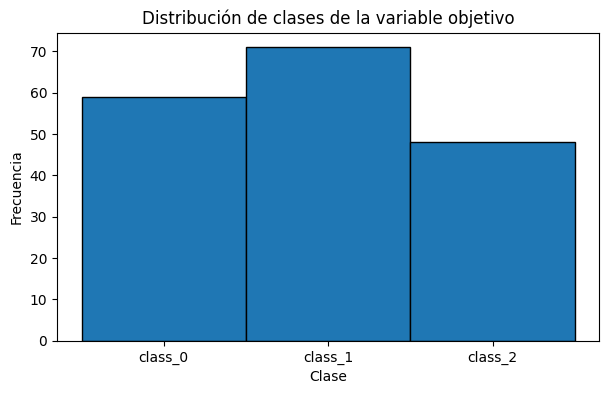

In [11]:
import matplotlib.pyplot as plt

class_counts = df['target'].value_counts().sort_index()

for class_id, count in class_counts.items():
    print(f'{wine.target_names[class_id]}: {count} elementos')

plt.figure(figsize=(7, 4))
plt.hist(df['target'], bins=[-0.5, 0.5, 1.5, 2.5], edgecolor='black')
plt.xticks([0, 1, 2], wine.target_names)
plt.title('Distribución de clases de la variable objetivo')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()

**Conclusión:** Aunque la Clase 1 tiene mayor representación en el dataset y la Clase 2 cuenta con menos observaciones, la diferencia entre clases no es lo suficientemente grande como para considerarse un problema severo de desbalanceo. Por lo tanto, el dataset mantiene una distribución aceptable para continuar con el proceso de entrenamiento y evaluación de modelos de clasificación multi-clase.

## Distribución Variables Numéricas

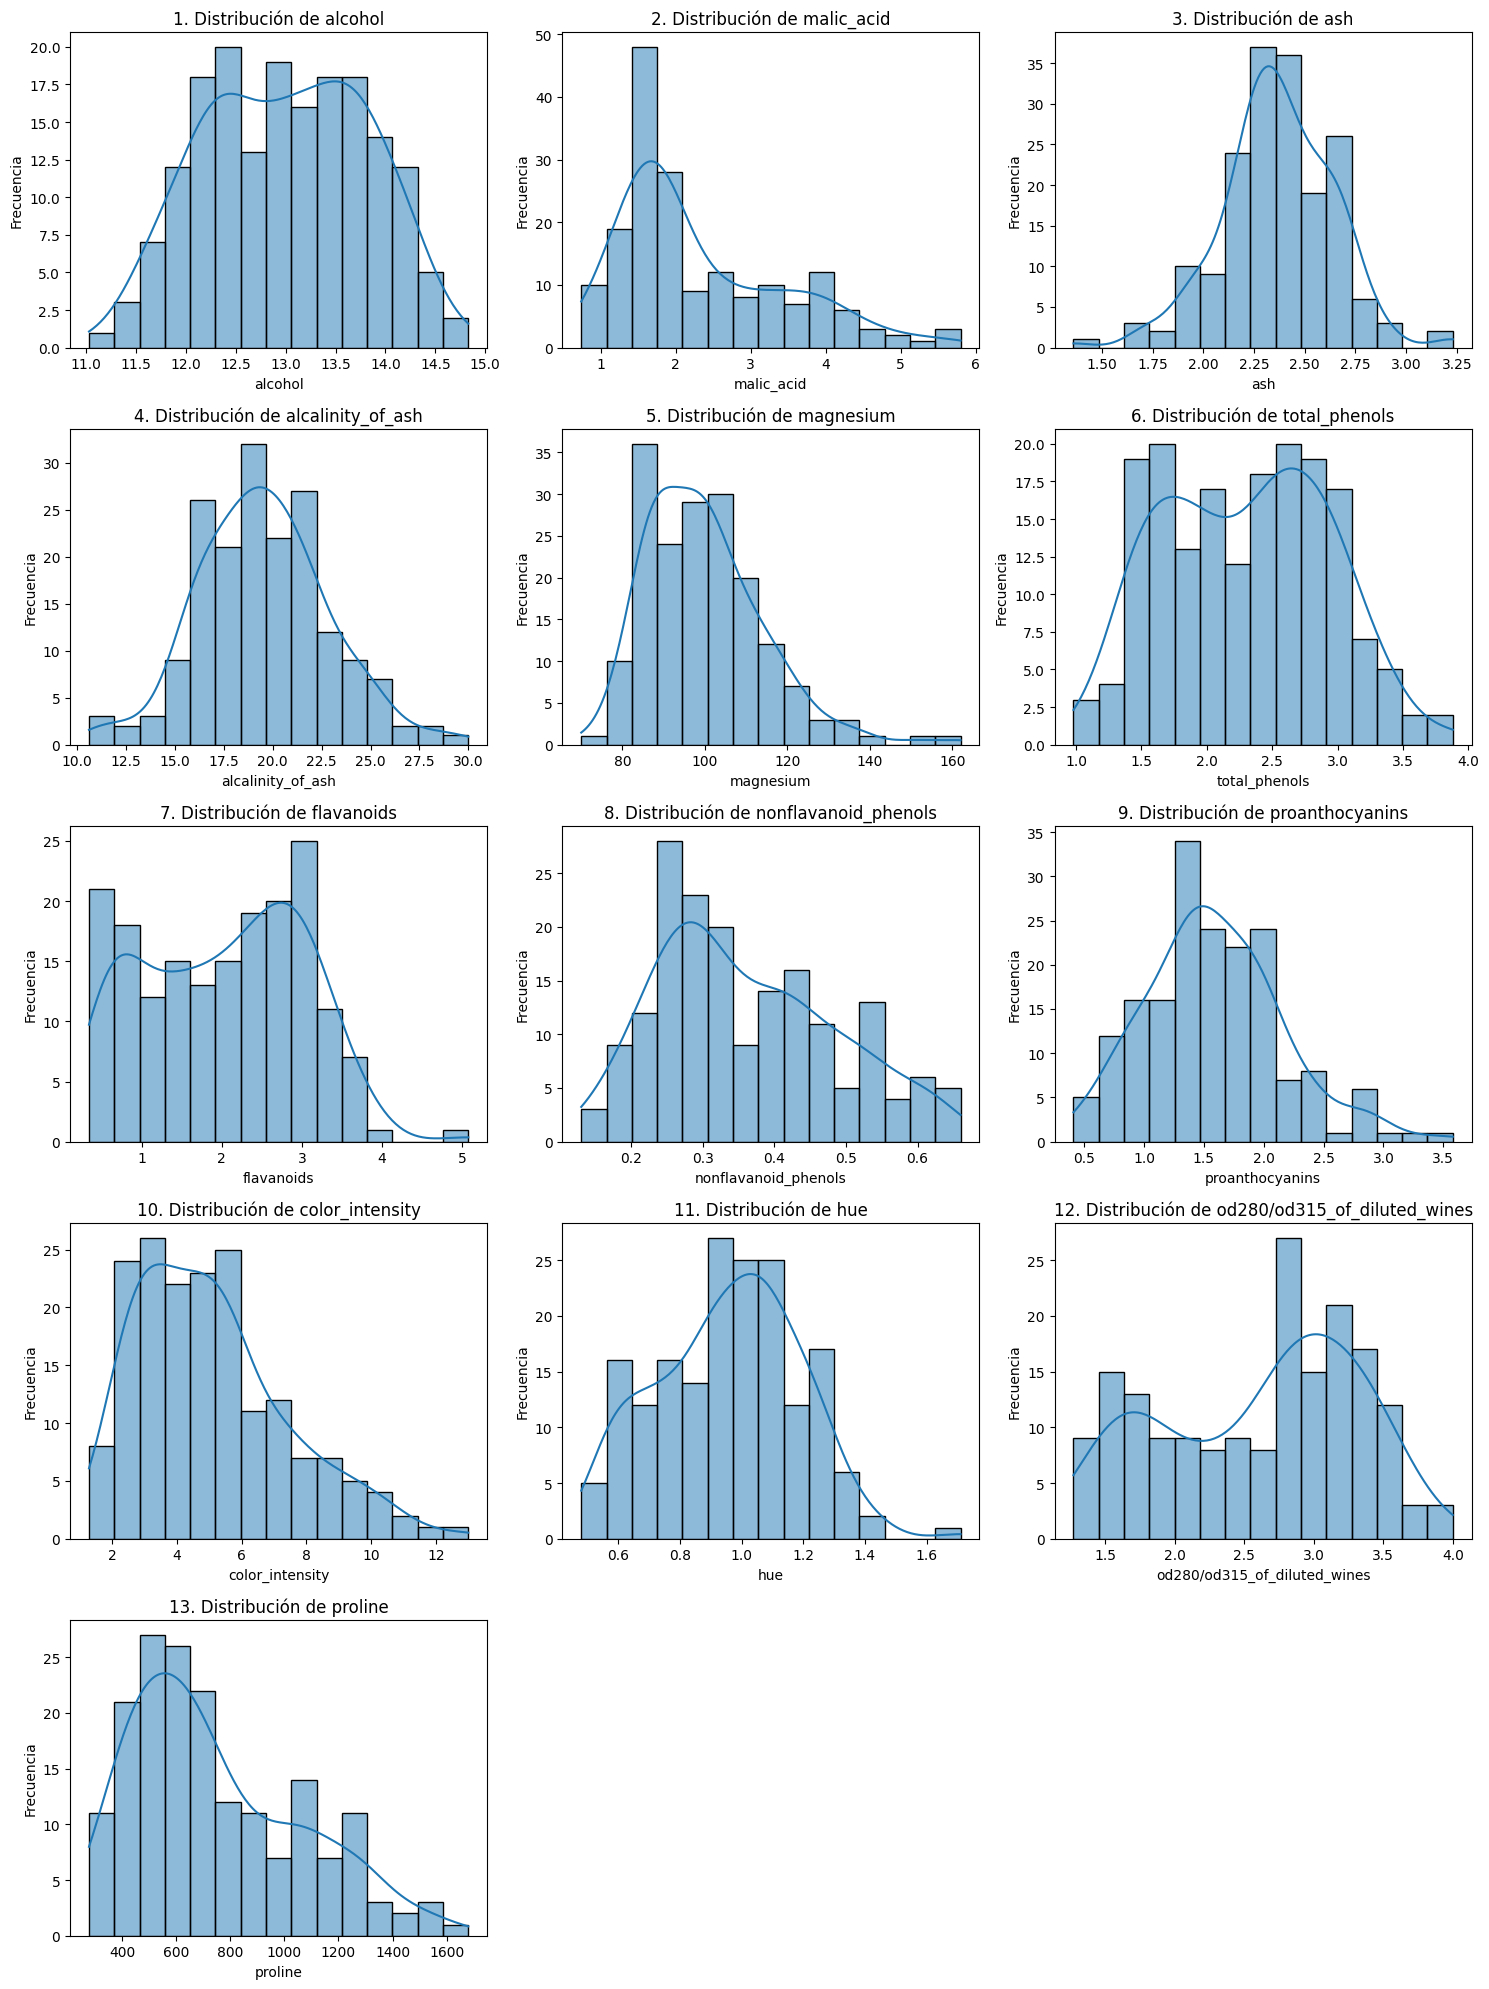

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric_histograms(dataframe, columns, bins=15):
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for index, column in enumerate(columns):
        if column in dataframe.columns:
            sns.histplot(data=dataframe, x=column, bins=bins, kde=True, ax=axes[index])
        else:
            axes[index].text(0.5, 0.5, f'Columna {column} no encontrada', ha='center')
            axes[index].axis('off')
            continue

        axes[index].set_title(f'{index + 1}. Distribución de {column}')
        axes[index].set_xlabel(column)
        axes[index].set_ylabel('Frecuencia')

    for index in range(len(columns), len(axes)):
        axes[index].axis('off')

    plt.tight_layout()
    plt.show()

numeric_feature_columns = df.select_dtypes(include=['number']).columns.drop('target')
plot_numeric_histograms(df, numeric_feature_columns)

## Observaciones por variable

| Variable | Observación |
|---|---|
| `alcohol` | Distribución uniforme / normal ensanchada y simétrica. Indica niveles bien balanceados ($11\%$ - $15\%$) sin concentración en un solo extremo. |
| `malic_acid` | Distribución exponencial / en `L` con fuerte sesgo a la derecha (+). La mayoría de los vinos tiene acidez baja; hay pocos con valores muy altos (atípicos). |
| `ash` | Distribución normal (gaussiana) y simétrica. Muestra un comportamiento natural estándar centrado entre 2.3 y 2.4. |
| `alcalinity_of_ash` | Distribución normal (gaussiana) y simétrica. Es un comportamiento clásico y predecible, centrado alrededor de 20.5. |
| `magnesium` | Distribución unimodal con cola larga, sesgada a la derecha (+). Lo típico es encontrar valores entre 80 y 110, pero existen ejemplares inusualmente altos. |
| `total_phenols` | Distribución bimodal y simétrica a nivel global. Evidencia claramente que hay dos poblaciones o clases distintas de vino mezcladas en los datos. |
| `flavanoids` | Distribución bimodal con ligero sesgo. Es una excelente variable predictiva, ya que separa el dataset en dos grupos definidos. |
| `nonflavanoid_phenols` | Distribución unimodal irregular, sesgada a la derecha (+). Existe una alta concentración en valores bajos (0.2 - 0.3) con un descenso gradual. |
| `proanthocyanins` | Distribución unimodal en campana, ligeramente sesgada a la derecha (+). Los datos se concentran entre 1.0 y 2.0, con sutiles valores atípicos altos. |
| `color_intensity` | Distribución unimodal con cola larga, fuertemente sesgada a la derecha (+). La mayoría de los vinos tiene un color tenue/moderado, pero hay una cola de vinos muy oscuros. |
| `hue` | Distribución normal achatada, con un ligero sesgo a la izquierda (-). Centrada en 1.0, decae de forma más abrupta en su límite inferior. |
| `od280/od315_of_diluted_wines` | Distribución bimodal con sesgo a la izquierda (-). Es la tercera variable clave que confirma la separación clara de dos grupos. |
| `proline` | Distribución unimodal escalonada, fuertemente sesgada a la derecha (+). Dominan los valores bajos (400-700) y son muy pocos los vinos con concentraciones altas. |


# Deteccion de Anomalias

## Zscore

In [13]:
symetrical_cols = [
    'alcohol',
    'ash',
    'alcalinity_of_ash',
    'hue'
]

Anomalies found in 'alcohol': 0
Empty DataFrame
Columns: [alcohol, z_score_alcohol]
Index: []


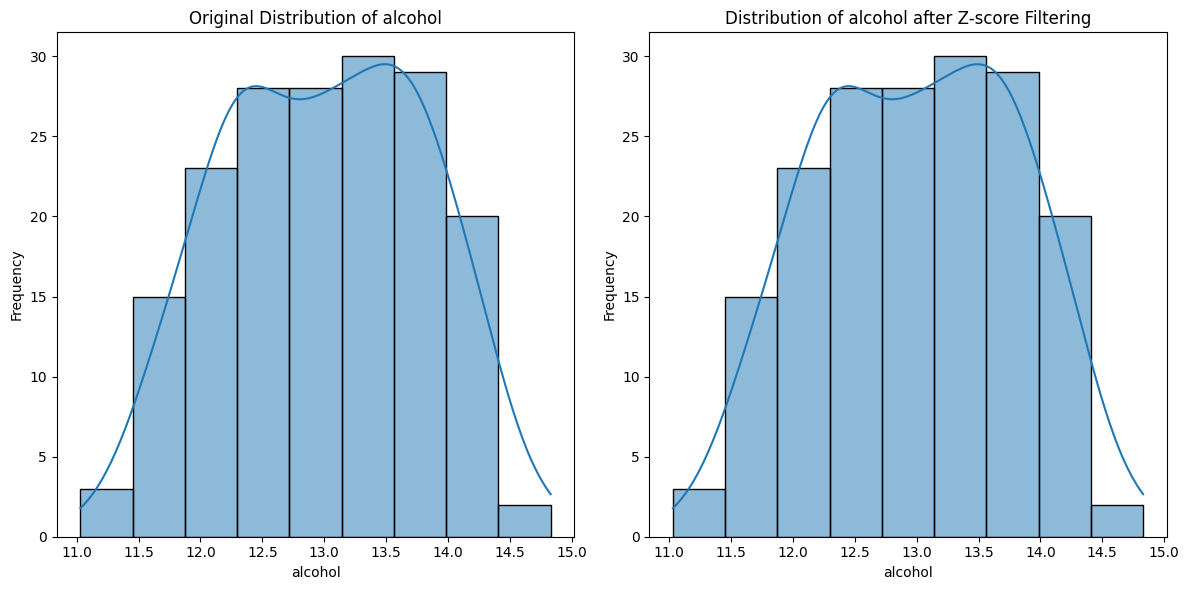

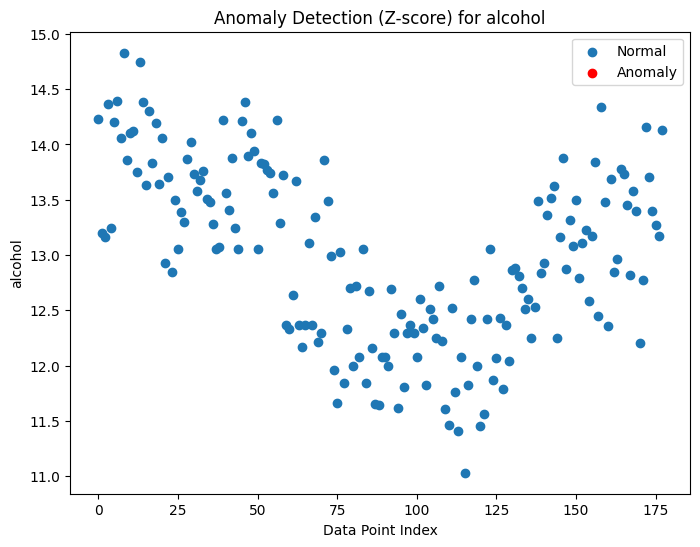

Anomalies found in 'ash': 3
      ash  z_score_ash
25   3.22     3.119772
59   1.36    -3.679162
121  3.23     3.156325


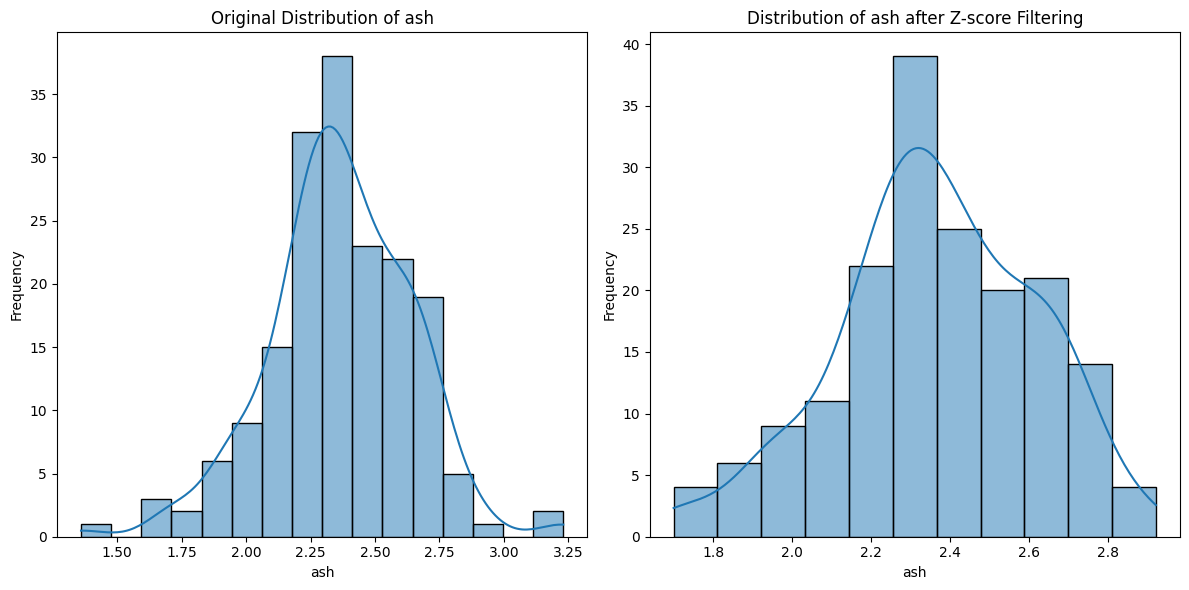

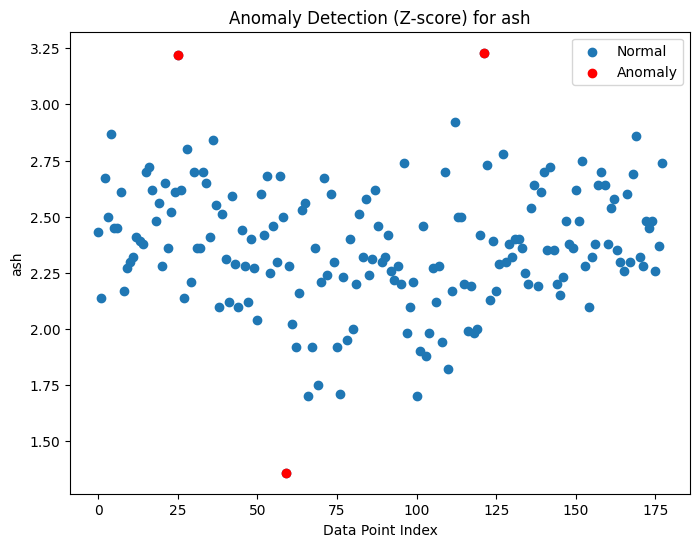

Anomalies found in 'alcalinity_of_ash': 1
    alcalinity_of_ash  z_score_alcalinity_of_ash
73               30.0                   3.300853


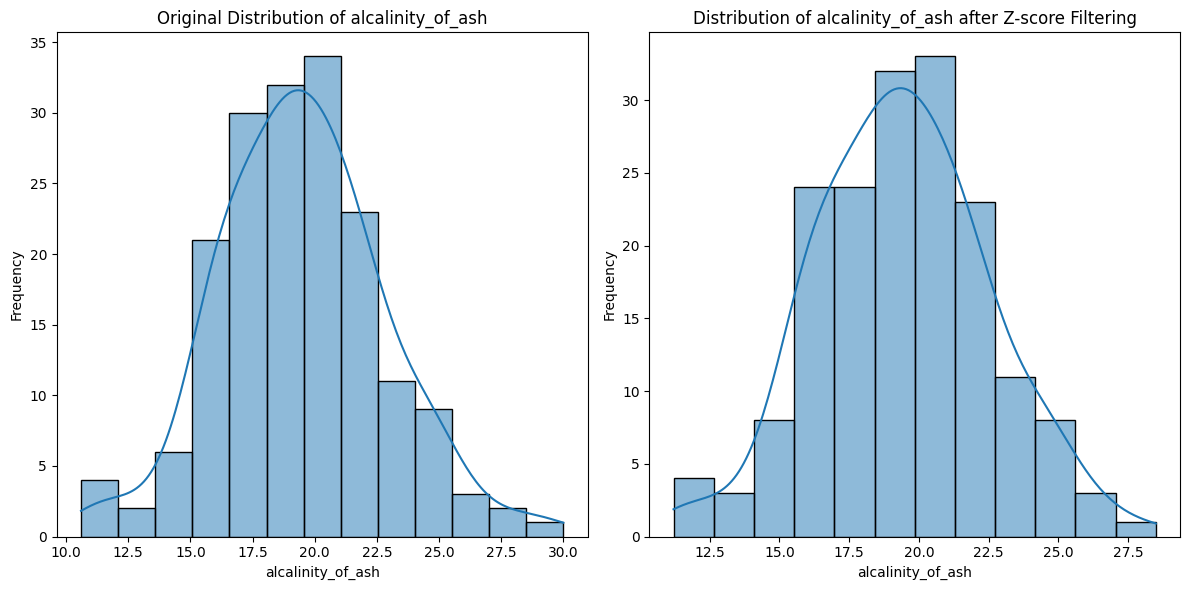

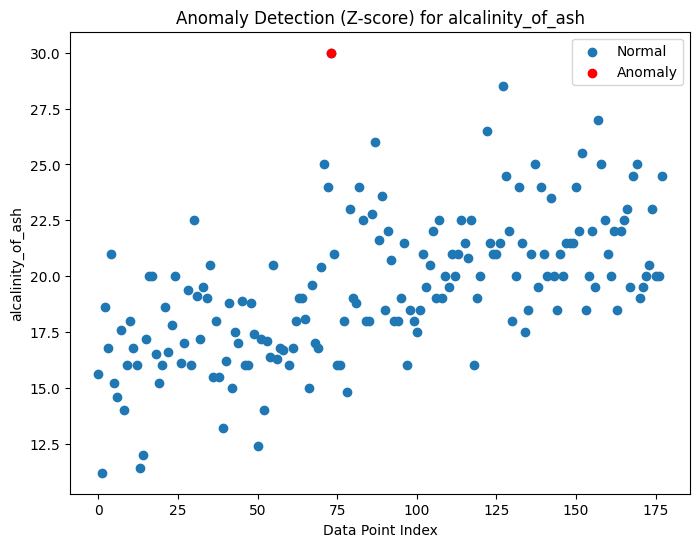

Anomalies found in 'hue': 1
      hue  z_score_hue
115  1.71     3.308821


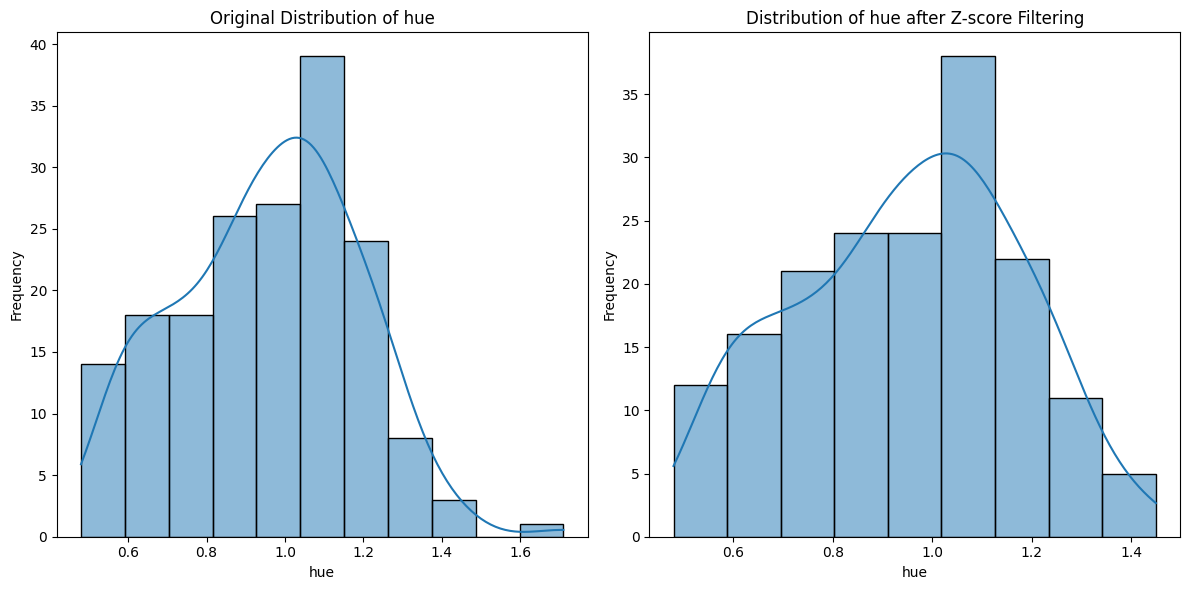

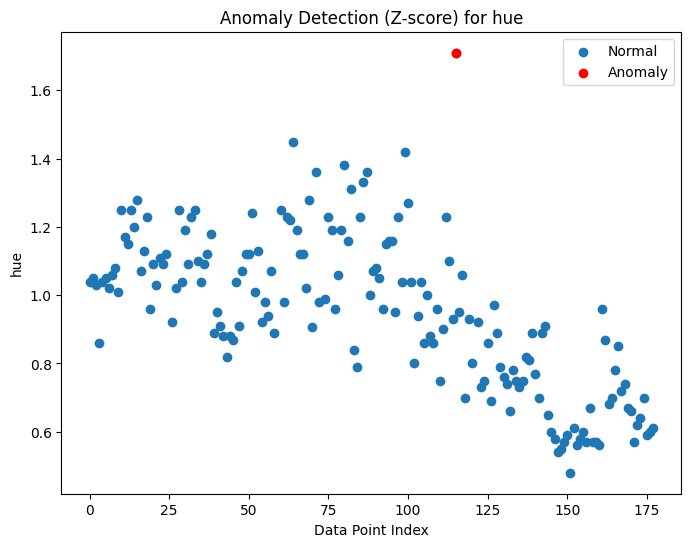

In [14]:
dataset_zscore = df.copy()

for col in symetrical_cols:
  if col in dataset_zscore.columns:
    # Calculate Z-scores
    dataset_zscore['z_score_' + col] = stats.zscore(dataset_zscore[col])

    # Anomaly threshold
    zscore_threshold = 3
    anomalies = dataset_zscore[(dataset_zscore['z_score_' + col].abs() > zscore_threshold)]

    print(f"Anomalies found in '{col}': {len(anomalies)}")
    print(anomalies[[col, 'z_score_' + col]])

    # Visualize the distribution before and after removing anomalies
    plt.figure(figsize=(12, 6))

    # Original distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Distribution after removing anomalies
    plt.subplot(1, 2, 2)
    sns.histplot(dataset_zscore[dataset_zscore['z_score_' + col].abs() <= zscore_threshold][col], kde=True)
    plt.title(f'Distribution of {col} after Z-score Filtering')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Scatter plot to highlight anomalies
    plt.figure(figsize=(8, 6))
    plt.scatter(dataset_zscore.index, dataset_zscore[col], label='Normal')
    plt.scatter(anomalies.index, anomalies[col], color='red', label='Anomaly')
    plt.title(f'Anomaly Detection (Z-score) for {col}')
    plt.xlabel('Data Point Index')
    plt.ylabel(col)
    plt.legend()
    plt.show()

    # Remove anomalies from the copied dataset
    dataset_zscore = dataset_zscore[dataset_zscore['z_score_' + col].abs() <= zscore_threshold].drop(columns=['z_score_' + col])
  else:
    print(f"Column '{col}' not found in the dataset.")

## Isolation Forest

In [15]:
isolation_forest_cols = [
    column for column in numeric_feature_columns
    if column not in symetrical_cols
]
print(isolation_forest_cols)

dataset_isolated_forest = df.copy()


['malic_acid', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'od280/od315_of_diluted_wines', 'proline']


Anomalías totales detectadas: 9


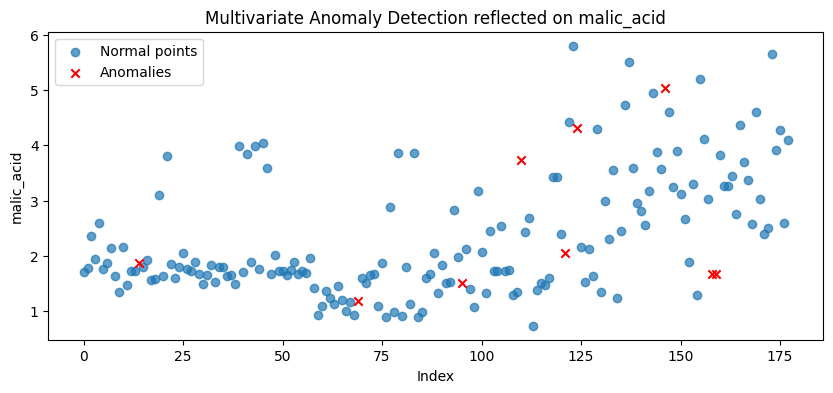

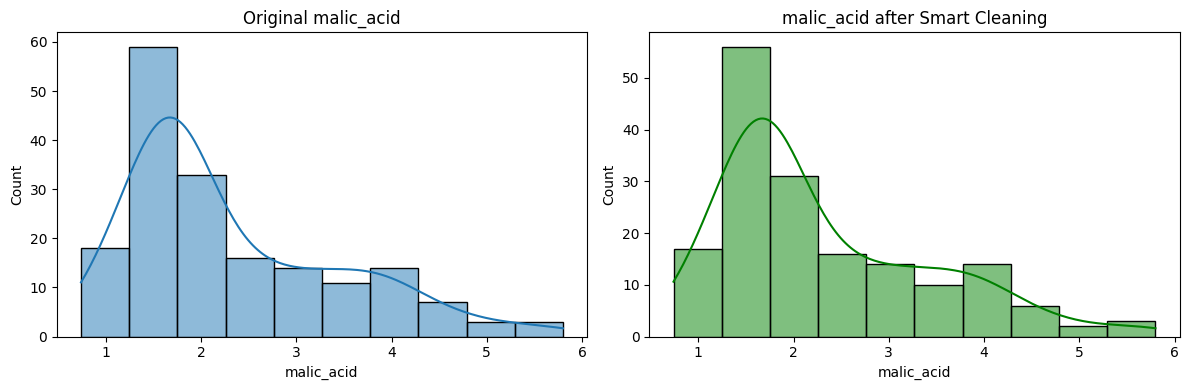

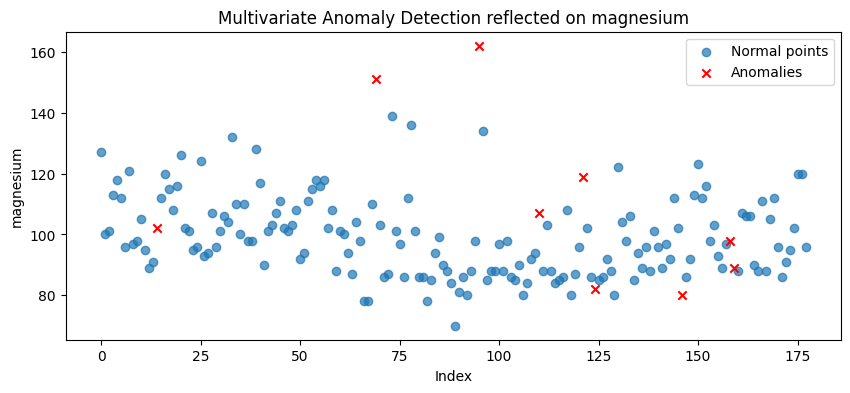

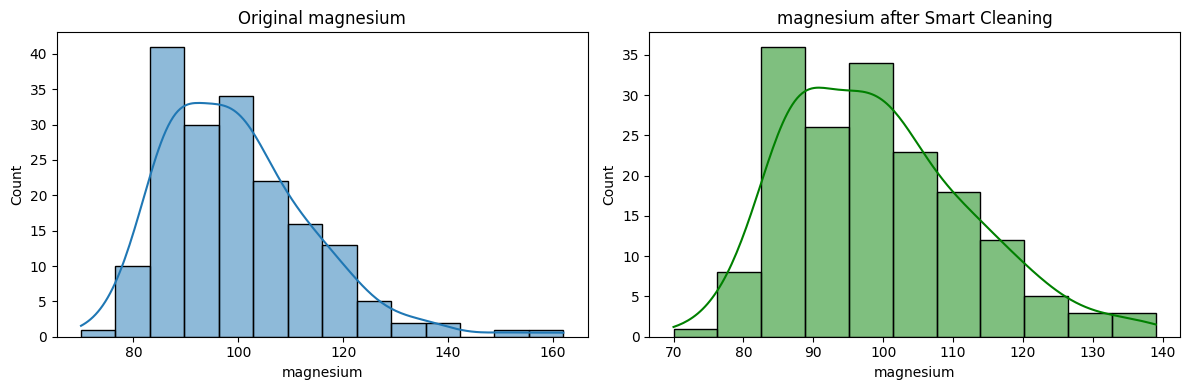

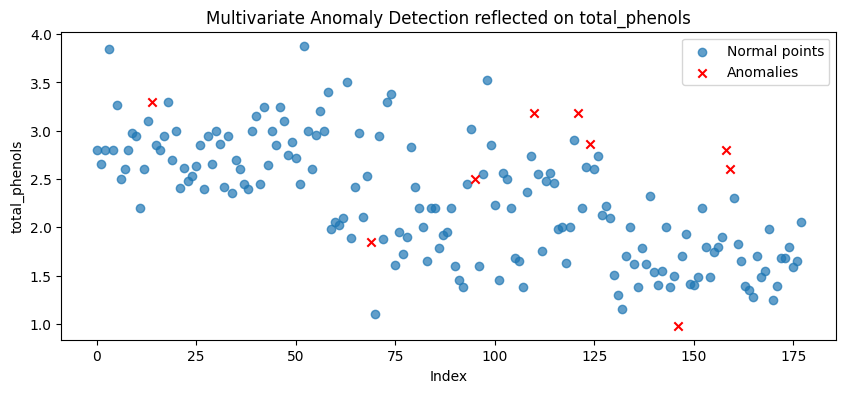

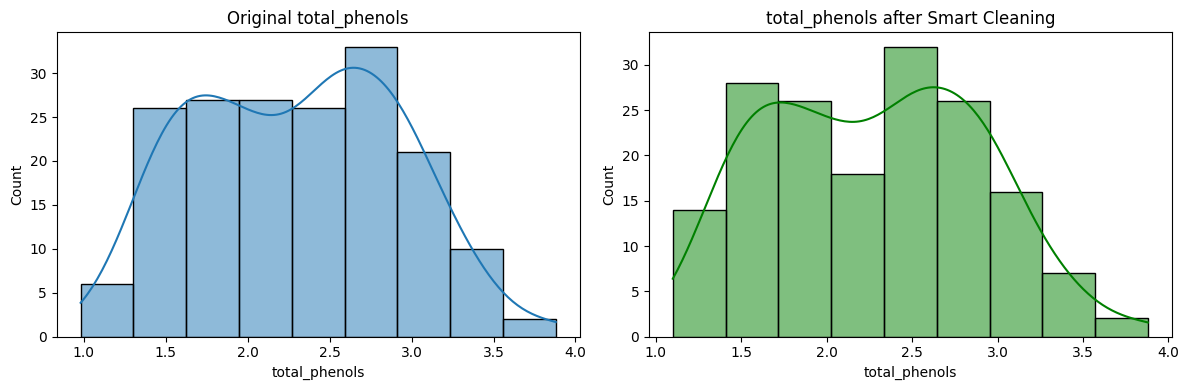

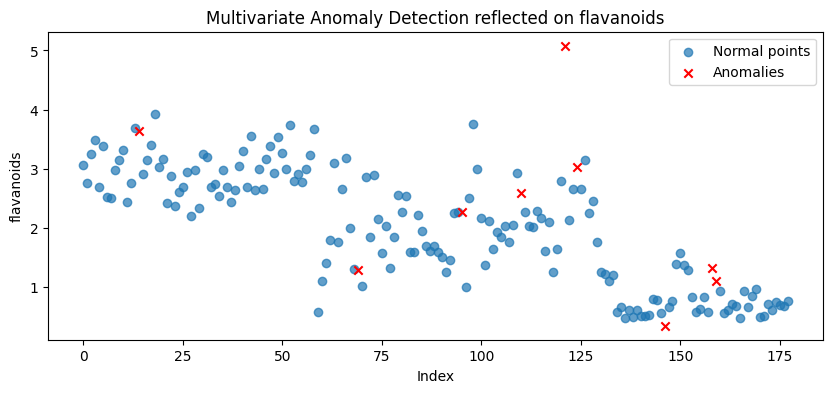

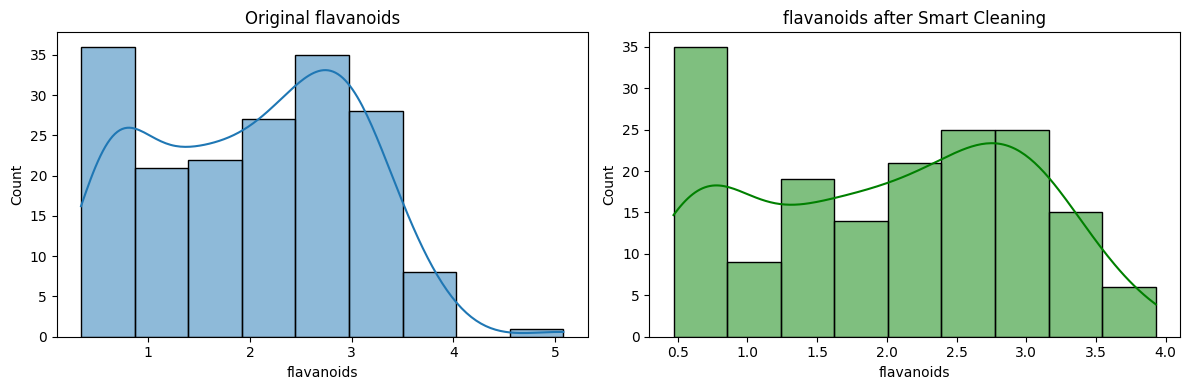

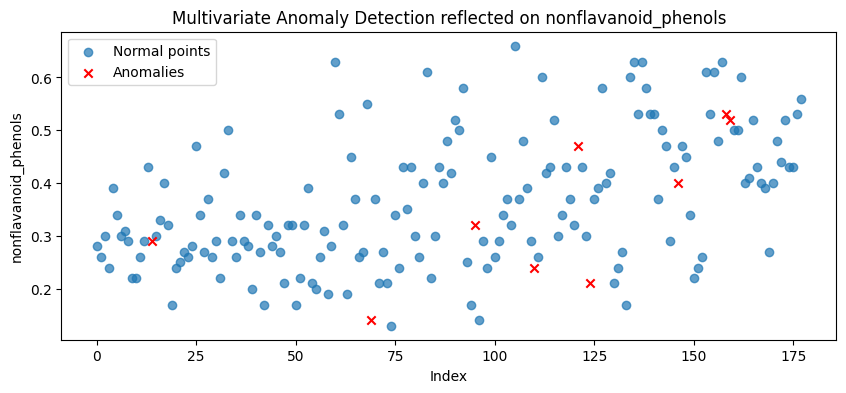

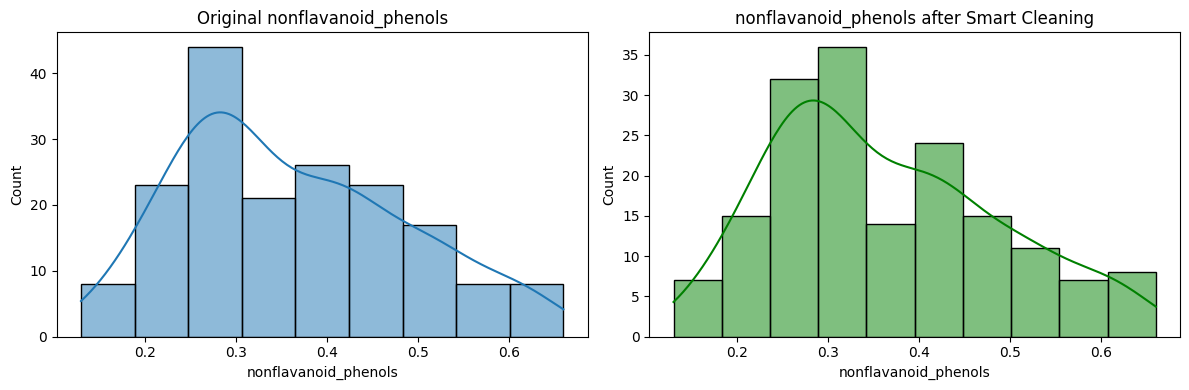

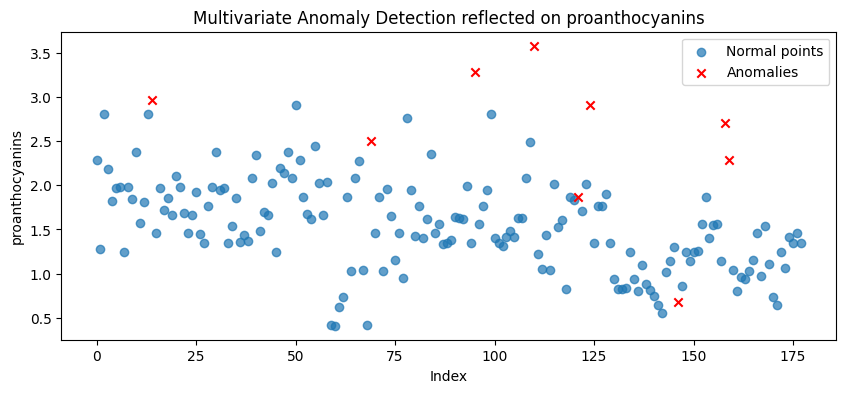

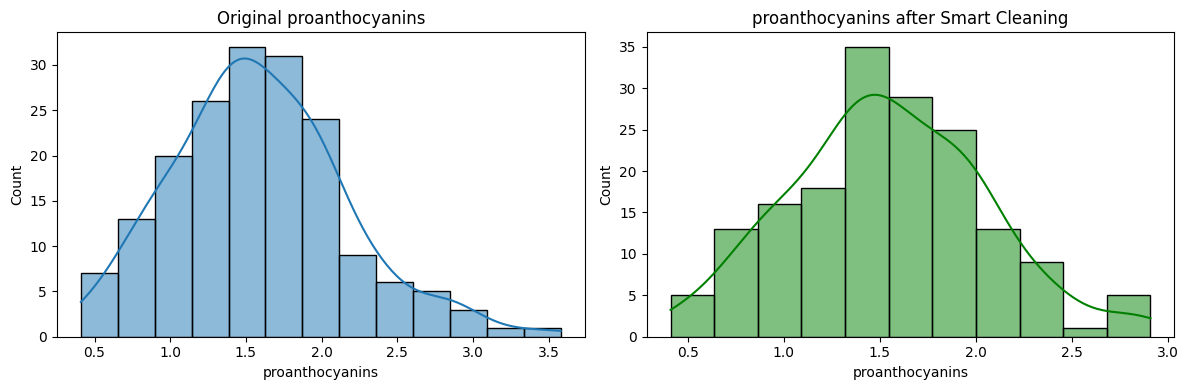

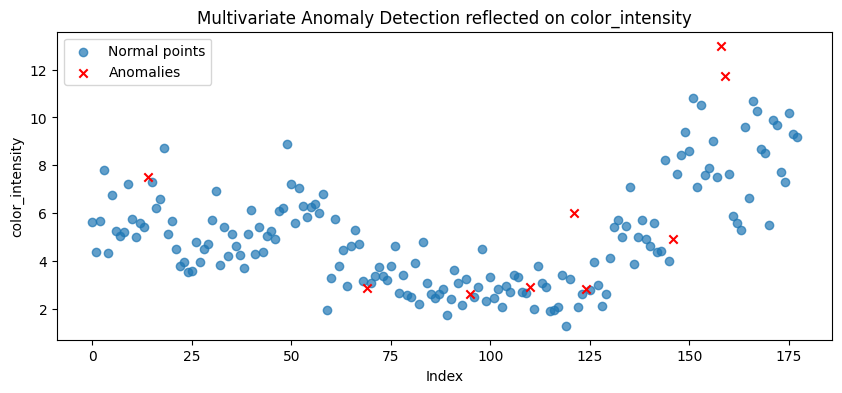

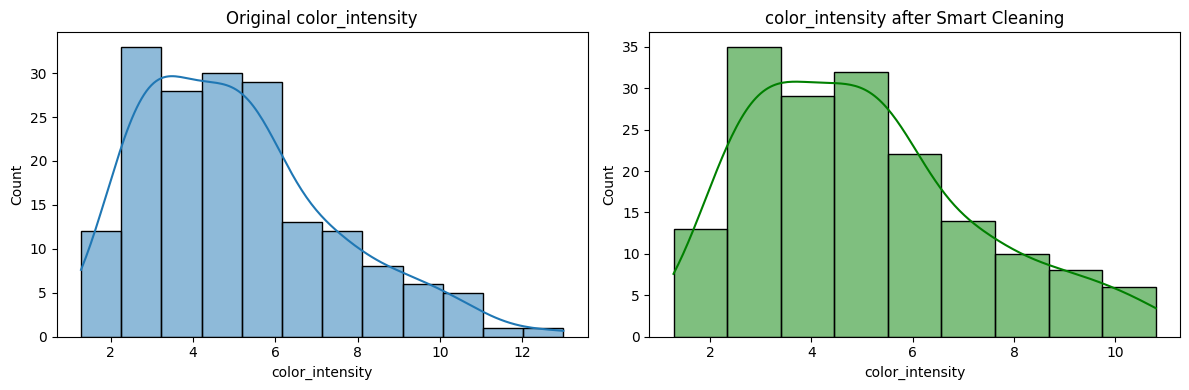

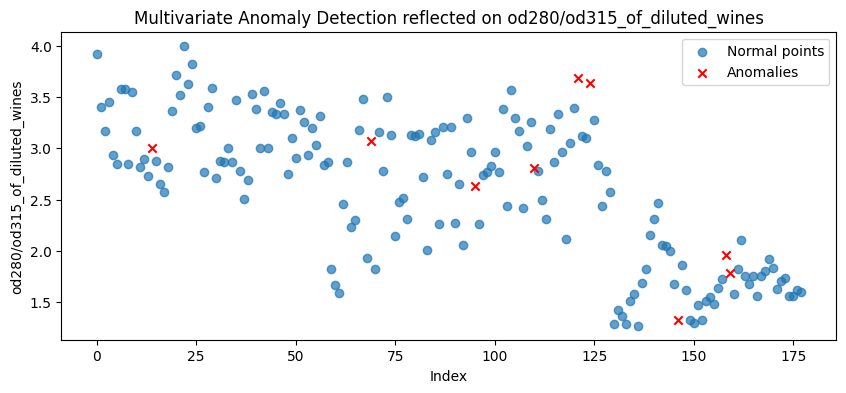

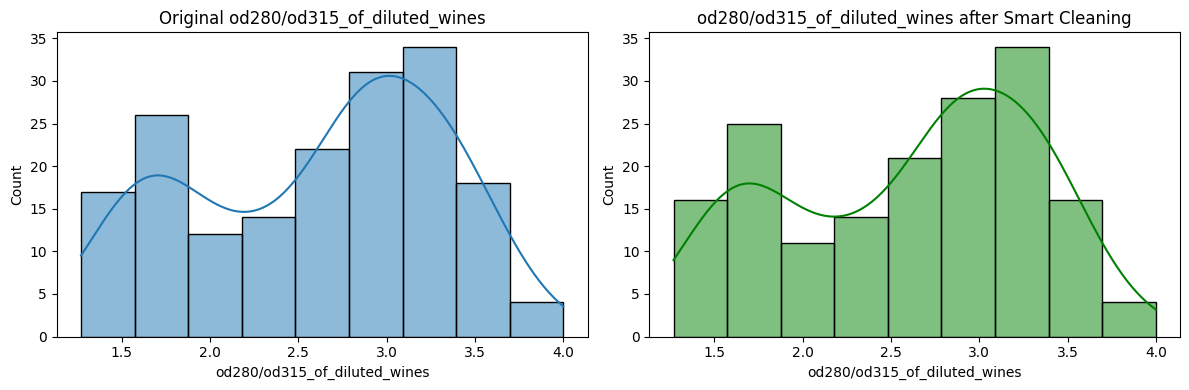

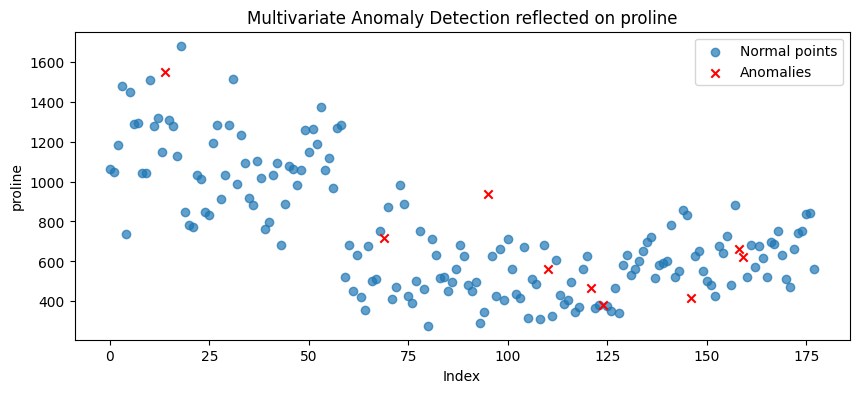

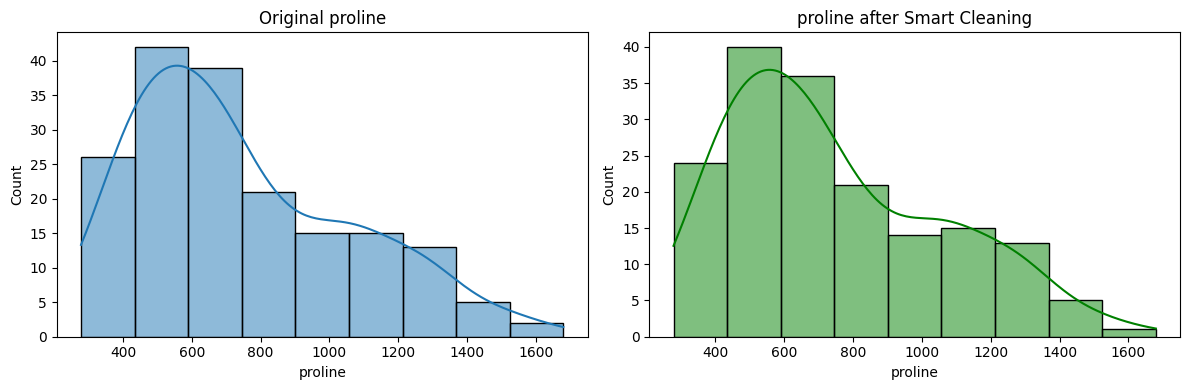

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar todas las columnas que quieres usar para el análisis
features = [col for col in isolation_forest_cols if col in dataset_isolated_forest.columns]
X_data = dataset_isolated_forest[features].values

# Optional pero recomendado: Escalar los datos para un comportamiento óptimo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# 2. Entrenar IF multidimensional con una contaminación controlada (ej. 5%)
# Si pones 0.05, le dices explícitamente que esperas que solo el 5% de tus vinos sean anomalías reales.
contamination_rate = 0.05
model = IsolationForest(contamination=contamination_rate, random_state=42)
model.fit(X_scaled)

# 3. Guardar las predicciones globales en el dataset
dataset_isolated_forest['is_anomaly_IF'] = model.predict(X_scaled)

# 4. Crear el dataset limpio libre de anomalías multivariables
datase_isolation_forest = dataset_isolated_forest[dataset_isolated_forest['is_anomaly_IF'] == 1].copy()

print(f"Anomalías totales detectadas: {(dataset_isolated_forest['is_anomaly_IF'] == -1).sum()}")

# ==========================================
# 5. Visualizar los resultados para cada columna
# ==========================================
for col in features:
    # Graficar dispersión de anomalías individuales basadas en la decisión GLOBAL
    plt.figure(figsize=(10, 4))
    # Puntos normales
    plt.scatter(dataset_isolated_forest.index[dataset_isolated_forest['is_anomaly_IF'] == 1],
                dataset_isolated_forest[col][dataset_isolated_forest['is_anomaly_IF'] == 1],
                label='Normal points', alpha=0.7)
    # Puntos anómalos (Corrección aquí: .index y marker='x')
    plt.scatter(dataset_isolated_forest.index[dataset_isolated_forest['is_anomaly_IF'] == -1],
                dataset_isolated_forest[col][dataset_isolated_forest['is_anomaly_IF'] == -1],
                color='red', label='Anomalies', marker='x')

    plt.title(f'Multivariate Anomaly Detection reflected on {col}')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.legend()
    plt.show()


    # Histogramas Comparativos
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(dataset_isolated_forest[col], kde=True)
    plt.title(f'Original {col}')

    plt.subplot(1, 2, 2)
    sns.histplot(datase_isolation_forest[col], kde=True, color='green')
    plt.title(f'{col} after Smart Cleaning')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

## Data Filtrada

In [17]:
# Dataset final libre de anomalías detectadas por Z-score e Isolation Forest
clean_indices = dataset_zscore.index.intersection(datase_isolation_forest.index)
dataset_clean = df.loc[clean_indices].copy()

print(f'Dimensiones originales: {df.shape}')
print(f'Dimensiones tras Z-score: {dataset_zscore.shape}')
print(f'Dimensiones tras Isolation Forest: {datase_isolation_forest.shape}')
print(f'Dimensiones finales limpias: {dataset_clean.shape}')

dataset_clean.head()

Dimensiones originales: (178, 14)
Dimensiones tras Z-score: (173, 14)
Dimensiones tras Isolation Forest: (169, 15)
Dimensiones finales limpias: (165, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# EDA

## Correlation Matrix

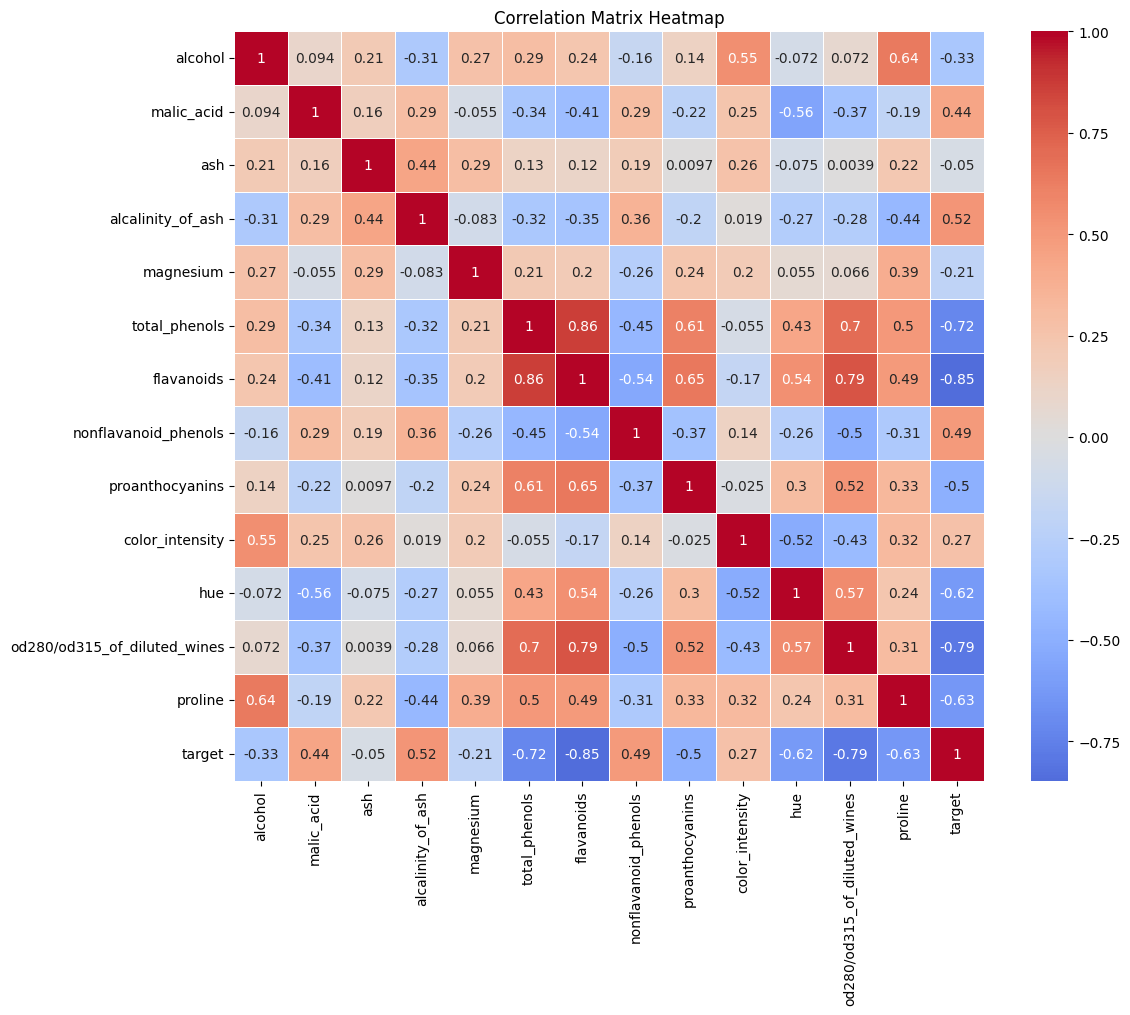

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

## Anova

In [19]:
# Trabajar sobre una copia para no modificar el dataset filtrado original
dataset_anova = dataset_clean.copy()
dataset_anova.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [20]:
from scipy.stats import f_oneway
import pandas as pd

anova_results = []
target_groups = sorted(dataset_anova['target'].unique())

for col in numeric_feature_columns:
    groups = [
        dataset_anova.loc[dataset_anova['target'] == target_value, col].dropna()
        for target_value in target_groups
    ]

    f_stat, p_value = f_oneway(*groups)
    anova_results.append({
        'feature': col,
        'f_stat': f_stat,
        'p_value': p_value,
    })

anova_results_df = pd.DataFrame(anova_results).sort_values('p_value')

# Add statistical significance column
p_value_threshold = 0.05
anova_results_df['Statistical Significance'] = anova_results_df['p_value'].apply(lambda x: 'Significant' if x < p_value_threshold else 'Not Significant')

display(anova_results_df)

,feature,f_stat,p_value,Statistical Significance
6,flavanoids,299.488611,3.798498e-55,Significant
12,proline,217.998844,1.143026e-46,Significant
11,od280/od315_of_diluted_wines,187.421436,7.130069e-43,Significant
0,alcohol,127.212010,6.142124e-34,Significant
9,color_intensity,117.590215,2.835966e-32,Significant
5,total_phenols,107.840632,1.673230e-30,Significant
10,hue,101.067848,3.223982e-29,Significant
8,proanthocyanins,45.848454,1.664129e-16,Significant
3,alcalinity_of_ash,42.637563,1.327704e-15,Significant
1,malic_acid,39.035549,1.456082e-14,Significant


## PCA

Explained variance ratio: [0.38600073 0.20347806]
Total explained variance: 0.5894787915781673


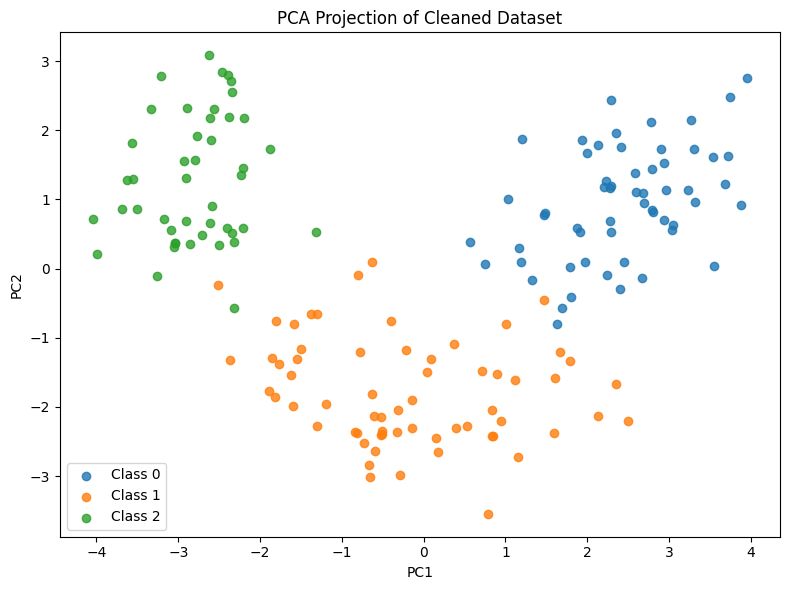

,PC1,PC2,target
0,3.533702,1.619613,0
1,2.399362,-0.300948,0
2,2.690094,0.945353,0
3,3.956057,2.753603,0
4,1.034055,1.009780,0


In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

pca_data = dataset_clean[numeric_feature_columns].copy()
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(pca_scaled)

pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2'],
    index=dataset_clean.index
)
pca_df['target'] = dataset_clean['target'].values

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
for target_value in sorted(pca_df['target'].unique()):
    subset = pca_df[pca_df['target'] == target_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Class {int(target_value)}', alpha=0.8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection of Cleaned Dataset')
plt.legend()
plt.tight_layout()
plt.show()

pca_df.head()

## Pair of Distribution

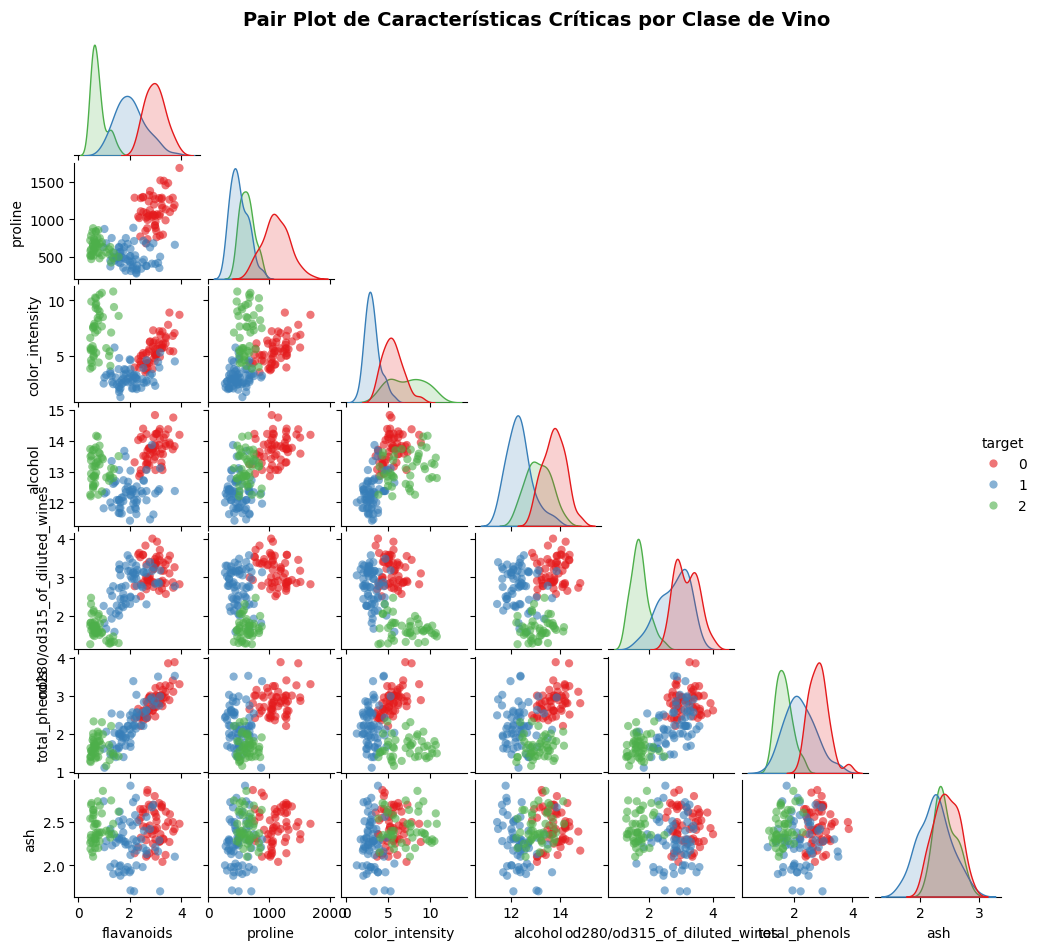

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos solo el "Dream Team" de tus variables según ANOVA
# Flavanoids y Proline (las mejores), Color Intensity (bimodal clave) y Alcohol
top_features = ['flavanoids', 'proline', 'color_intensity', 'alcohol', 'od280/od315_of_diluted_wines', 'total_phenols', 'ash']

# 2. Preparamos los datos igual que antes pero solo con el Top
pairplot_data = dataset_clean[top_features].copy()
pairplot_data['target'] = dataset_clean['target'].values

# 3. Construimos el pairplot estilizado
g = sns.pairplot(
    pairplot_data,
    vars=top_features,
    hue='target',
    palette='Set1',        # Paleta con colores más vivos y distinguibles
    diag_kind='kde',       # Cambiamos a curvas de densidad suaves
    corner=True,           # Mantenemos tu excelente idea del corte diagonal
    height=3.0,            # Ajustamos el tamaño individual de cada sub-gráfico
    aspect=1.2,
    plot_kws={
        'alpha': 0.6,      # Un toque más de transparencia para ver solapamientos
        's': 35,           # Puntos ligeramente más grandes para que resalten
        'edgecolor': 'none' # Eliminamos el borde blanco de los puntos para limpiar la vista
    },
    diag_kws={
        'fill': True,      # Rellenamos el fondo de las curvas de densidad
        'alpha': 0.2       # Opacidad muy suave para el relleno de la diagonal
    }
)

# 4. Ajustamos el tamaño global (ahora mucho más compacto y nítido)
g.fig.set_size_inches(10, 9)
plt.suptitle('Pair Plot de Características Críticas por Clase de Vino', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Observaciones

- **Selección de Variables (ANOVA y Matriz de Correlación):** La prueba ANOVA y la Matriz de Correlación coinciden en que flavanoids y proline son los predictores químicos más potentes para discriminar las clases de vino. Por el contrario, ash demostró un impacto estadístico nulo (correlación de $-0.05$ y F-score mínimo), por lo que se recomienda su eliminación.
- **Redundancia (Matriz de Correlación y Pairplot):** Existe una alta multicolinealidad entre compuestos fenólicos (total_phenols vs flavanoids con $0.86$). El Pairplot refleja visualmente esta relación lineal perfecta, sugiriendo eliminar total_phenols si se van a utilizar modelos lineales para evitar redundancia.
- **Estrategia de Modelado (PCA y Pairplot):** La proyección bidimensional del PCA y las distribuciones del Pairplot demuestran de forma contundente que las tres clases de vino se agrupan en clusters densos con un solapamiento mínimo.

# Scaling

Dimensiones finales del dataset escalado y filtrado: (165, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,1.541411,-0.573138,0.258840,-1.230664,2.244114,0.855679,1.078828,-0.668178,1.488522,0.263881,0.395244,1.867415,1.000526,0
1,0.224552,-0.509779,-0.928648,-2.660889,0.083421,0.612504,0.769485,-0.830190,-0.516021,-0.311542,0.441287,1.129803,0.952743,0
2,0.173412,0.015195,1.241589,-0.255510,0.163446,0.855679,1.264435,-0.506165,2.520564,0.282148,0.349201,0.803551,1.382790,0
3,1.720401,-0.355907,0.545475,-0.840602,1.123755,2.557899,1.522221,-0.992202,1.270206,1.250321,-0.433529,1.200727,2.322520,0
4,0.275692,0.223375,2.060546,0.524613,1.523883,0.855679,0.697305,0.222890,0.555715,-0.338943,0.395244,0.463114,-0.050698,0



--- Comparación de distribuciones antes y después del escalado ---


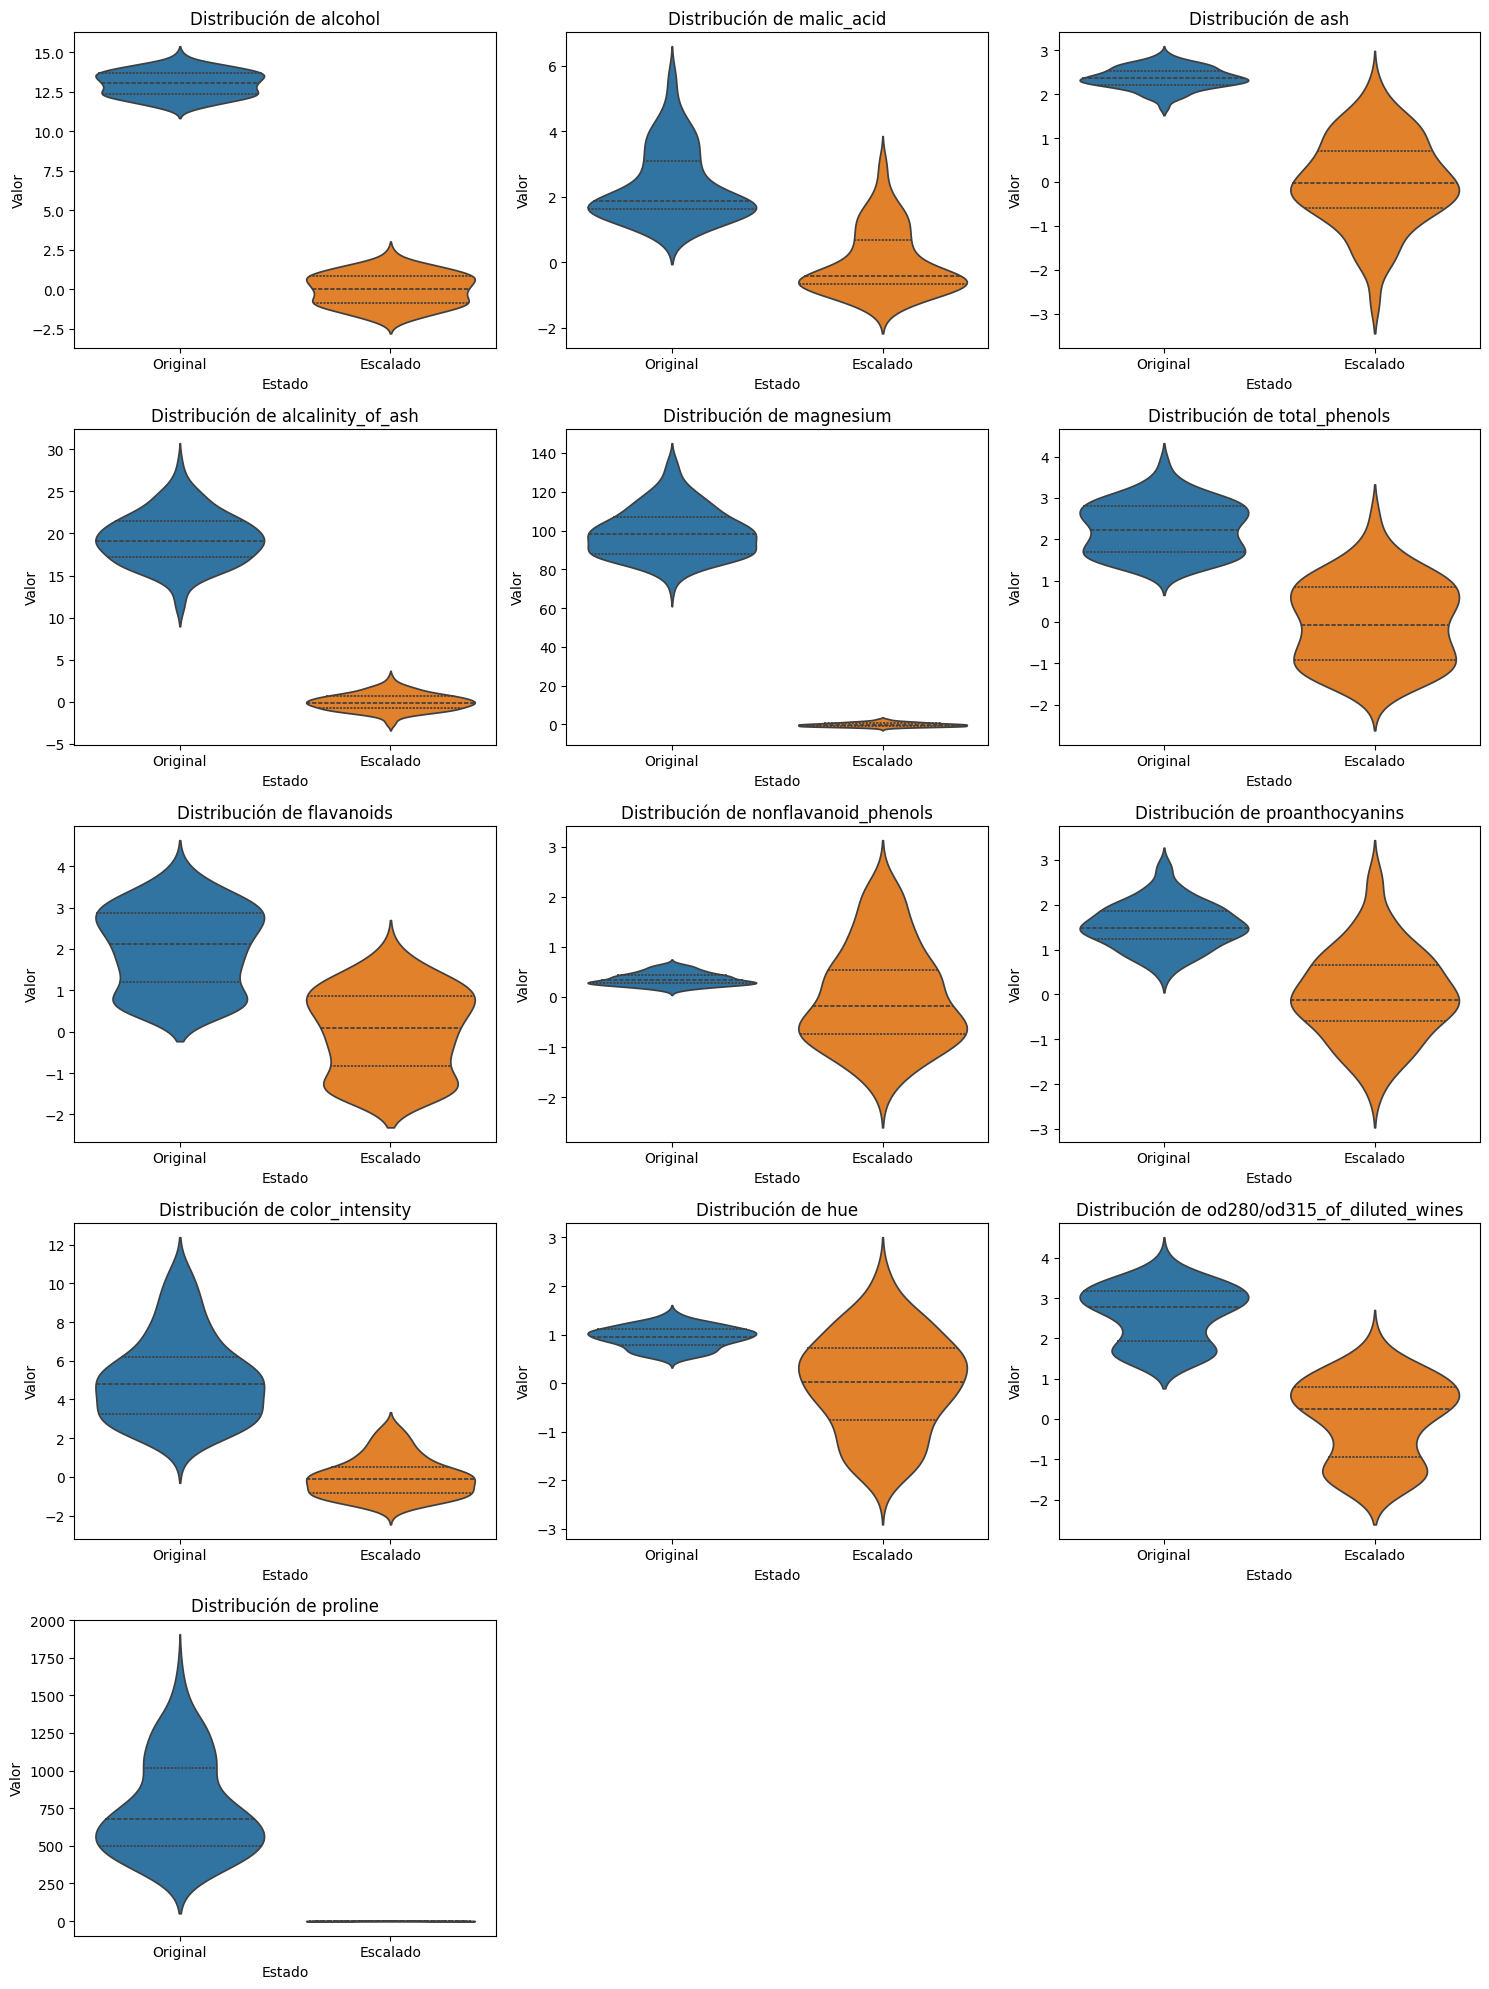

In [23]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Separar características (X) y variable objetivo (y) del dataset limpio
dataset_to_scale = dataset_clean.copy()
X = dataset_to_scale.drop(columns=['target'])
y = dataset_to_scale['target']

# Inicializar y aplicar StandardScaler a TODAS las características numéricas
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X)

# Reconstruir el DataFrame escalado con todas las características
X_scaled_df = pd.DataFrame(X_scaled_full, columns=X.columns, index=X.index)

dataset_scaled = X_scaled_df.copy() # Usar .copy() para evitar SettingWithCopyWarning
dataset_scaled['target'] = y

print(f"Dimensiones finales del dataset escalado y filtrado: {dataset_scaled.shape}")
display(dataset_scaled.head())

# --- Comparación de distribuciones antes y después del escalado ---
print("\n--- Comparación de distribuciones antes y después del escalado ---")

# Seleccionar las características a comparar (todas las que fueron escaladas)
features_to_compare = X.columns

num_features = len(features_to_compare)
n_cols = 3 # Número de columnas para los subplots
n_rows = (num_features + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(features_to_compare):
    plt.subplot(n_rows, n_cols, i + 1)

    # Crear un DataFrame temporal para el violinplot
    temp_df_comparison = pd.DataFrame({
        'Original': dataset_to_scale[col],
        'Escalado': X_scaled_df[col]
    })

    sns.violinplot(data=temp_df_comparison, inner='quartile')
    plt.title(f'Distribución de {col}')
    plt.ylabel('Valor')
    plt.xlabel('Estado')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separar características (X) y variable objetivo (y) del dataset limpio
X = dataset_clean.drop(columns=['target'])
y = dataset_clean['target']

# Inicializar y aplicar StandardScaler a TODAS las características numéricas
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X)

# Reconstruir el DataFrame escalado con todas las características (sin eliminar ninguna)
X_scaled_df = pd.DataFrame(X_scaled_full, columns=X.columns, index=X.index)

# Combinar todas las características escaladas con la variable objetivo
dataset_scaled = X_scaled_df.copy() # Usar .copy() para evitar SettingWithCopyWarning
dataset_scaled['target'] = y

print(f"Dimensiones de las características escaladas (X): {X_scaled_df.shape}")
print(f"Dimensiones finales del dataset escalado (todas las características): {dataset_scaled.shape}")
display(dataset_scaled.head())

Dimensiones de las características escaladas (X): (165, 13)
Dimensiones finales del dataset escalado (todas las características): (165, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,1.541411,-0.573138,0.258840,-1.230664,2.244114,0.855679,1.078828,-0.668178,1.488522,0.263881,0.395244,1.867415,1.000526,0
1,0.224552,-0.509779,-0.928648,-2.660889,0.083421,0.612504,0.769485,-0.830190,-0.516021,-0.311542,0.441287,1.129803,0.952743,0
2,0.173412,0.015195,1.241589,-0.255510,0.163446,0.855679,1.264435,-0.506165,2.520564,0.282148,0.349201,0.803551,1.382790,0
3,1.720401,-0.355907,0.545475,-0.840602,1.123755,2.557899,1.522221,-0.992202,1.270206,1.250321,-0.433529,1.200727,2.322520,0
4,0.275692,0.223375,2.060546,0.524613,1.523883,0.855679,0.697305,0.222890,0.555715,-0.338943,0.395244,0.463114,-0.050698,0


# Split Train-Test

Finalmente, realizaremos  la división 80/20 estratificada de los datos, utilizando el conjunto de características ya seleccionadas y escaladas.

In [25]:
from sklearn.model_selection import train_test_split

# Ahora usamos 'dataset_scaled' (que ya está filtrado) para las características
# y la 'target' del dataset_clean original (o el filtrado, si 'target' no fue eliminada)

X = dataset_scaled.drop(columns=['target'])
y = dataset_clean['target'] # Usamos la columna target del dataset filtrado para estratificar

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Asegura que las proporciones de las clases se mantengan en train y test
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nDistribución de clases en y_train:")
display(y_train.value_counts(normalize=True))

print("\nDistribución de clases en y_test:")
display(y_test.value_counts(normalize=True))

Dimensiones de X_train: (132, 13)
Dimensiones de X_test: (33, 13)
Dimensiones de y_train: (132,)
Dimensiones de y_test: (33,)

Distribución de clases en y_train:


,proportion
target,
1,0.378788
0,0.348485
2,0.272727



Distribución de clases en y_test:


,proportion
target,
1,0.393939
0,0.333333
2,0.272727


### Justificación de la Partición Train/Test (80/20)

Se seleccionó una división 80/20 estratificada (`stratify=y`) por las siguientes razones clave:

*   **Dataset Pequeño (~169 datos):** Un split 70/30 dejaría muy pocas muestras en el conjunto de entrenamiento (118). Al elegir 80/20, maximizamos el entrenamiento a ~135 datos, dándole más herramientas a los modelos para aprender patrones estables.
*   **Complejidad de los Modelos:** Tanto la Red Neuronal como XGBoost necesitan la mayor cantidad de datos posible en su fase de ajuste (`fit`) para calibrar sus parámetros correctamente y evitar el sobreajuste (`overfitting`).
*   **Alta Separabilidad:** Como el EDA demostró (mediante PCA y Pairplot) que las clases de vino se separan de forma casi perfecta en el espacio, un 20% de test (~34 datos) es matemáticamente suficiente para obtener una evaluación confiable y robusta.
*   **Garantía de Balance (Estratificación):** El uso de `stratify=y` asegura que tanto el bloque de entrenamiento como el de prueba mantengan la misma proporción original de las tres clases de vino, evitando sesgos en la medición del rendimiento.

# Selección de Características

Basado en los hallazgos del análisis exploratorio de datos (EDA), específicamente la Matriz de Correlación y el ANOVA, se han identificado las siguientes características como potencialmente irrelevantes o redundantes:

*   **`ash`**: La prueba ANOVA indicó que esta característica tiene un impacto estadístico nulo en la distinción de las clases de vino. Mantenerla añadiría ruido sin aportar valor predictivo.
*   **`total_phenols`**: Se observó una alta multicolinealidad con `flavanoids` (correlación de 0.86). Para evitar redundancia y posibles problemas en la interpretabilidad del modelo (especialmente en modelos lineales), `total_phenols` fue identificada como candidata a ser eliminada.

Sin embargo, para permitir un análisis más completo de la importancia de las características después del entrenamiento del modelo (por ejemplo, a través de la importancia de las características del modelo), **no se realizará ninguna acción de eliminación o selección de características en esta etapa**. Todas las características se mantendrán en el conjunto de datos para el entrenamiento inicial, y la decisión final sobre la selección de características se tomará basándose en un análisis post-entrenamiento.

# Implementación y Fase de Experimentación de Modelos

En esta sección se evalúa el rendimiento de tres familias de modelos predictivos con distintas naturalezas algorítmicas:
* Random Forest (ensamble por bagging),
* XGBoost (ensamble por boosting secuencial) y
* Red Neuronal Artificial (aprendizaje profundo mediante backpropagation).

Con el objetivo de encontrar la combinación óptima que maximice la capacidad de generalización y mitigue el sobreajuste (overfitting), se adopta una metodología de experimentación iterativa. Por cada familia de modelos se ejecutarán 5 experimentos variando sistemáticamente sus hiperparámetros críticos y arquitecturas.

Para garantizar la reproducibilidad y el correcto análisis comparativo, los resultados de rendimiento en los conjuntos de entrenamiento (train) y prueba (test) se registrarán dinámicamente en una bitácora persistente en disco (bitacora_experimentos.csv), calculando métricas robustas de clasificación multiclase (Accuracy, Precision Macro, Recall Macro y F1-Score Macro).

### Configuración de la Bitácora y Funciones Auxiliares

In [26]:
import os
import pandas as pd
import numpy as np
import time  # <--- Agregado para la medición del tiempo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Added for XGBoost
import xgboost as xgb

# Added for Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

BITACORA = "bitacora_experimentos.csv"

def metricas(y_true, y_pred, sufijo):
    return {
        f"precision_{sufijo}": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"recall_{sufijo}":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"f1_{sufijo}":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"accuracy_{sufijo}":  accuracy_score(y_true, y_pred),
    }

# Se añade el parámetro 'tiempo_entrenamiento' a la función
def registrar(exp_id, modelo_nombre, hiperparams, arquitectura, model,
              X_train_data, y_train_labels_or_one_hot,
              X_test_data, y_test_labels_or_one_hot,
              tiempo_entrenamiento=0.0,
              y_pred_train_override=None, # Nuevo parámetro para predicciones de train pre-calculadas
              y_pred_test_override=None): # Nuevo parámetro para predicciones de test pre-calculadas

    # Convert y_true to labels if one-hot encoded for metric calculation
    if y_train_labels_or_one_hot.ndim > 1 and y_train_labels_or_one_hot.shape[1] > 1:
        y_train_for_metrics = np.argmax(y_train_labels_or_one_hot, axis=1)
    else:
        y_train_for_metrics = y_train_labels_or_one_hot

    if y_test_labels_or_one_hot.ndim > 1 and y_test_labels_or_one_hot.shape[1] > 1:
        y_test_for_metrics = np.argmax(y_test_labels_or_one_hot, axis=1)
    else:
        y_test_for_metrics = y_test_labels_or_one_hot

    # Determine y_pred_train
    if y_pred_train_override is not None:
        y_pred_train = y_pred_train_override
    elif 'tensorflow' in str(type(model)) or 'keras' in str(type(model)):
        y_pred_proba_train = model.predict(X_train_data, verbose=0)
        y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    elif model is not None:
        y_pred_train = model.predict(X_train_data)
    else:
        raise ValueError("Cannot calculate train predictions: model is None and y_pred_train_override was not provided.")

    # Determine y_pred_test
    if y_pred_test_override is not None:
        y_pred_test = y_pred_test_override
    elif 'tensorflow' in str(type(model)) or 'keras' in str(type(model)):
        y_pred_proba_test = model.predict(X_test_data, verbose=0)
        y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    elif model is not None:
        y_pred_test = model.predict(X_test_data)
    else:
        raise ValueError("Cannot calculate test predictions: model is None and y_pred_test_override was not provided.")

    # Base de la fila del CSV incluyendo el nuevo campo de costo computacional
    fila = {
        "experimento_id": exp_id,
        "modelo": modelo_nombre,
        "hiperparametros": str(hiperparams),
        "arquitectura": arquitectura,
        "tiempo_entrenamiento_seg": tiempo_entrenamiento # <--- Inyección en la bitácora
    }

    fila.update(metricas(y_train_for_metrics, y_pred_train, "train"))
    fila.update(metricas(y_test_for_metrics, y_pred_test, "test"))

    pd.DataFrame([fila]).to_csv(BITACORA, mode="a",
        header=not os.path.exists(BITACORA), index=False)

def build_keras_model(input_dim, num_classes, architecture_cfg):
    model = Sequential()
    first_layer = True # Flag to handle input_shape
    for layer_cfg in architecture_cfg['layers']:
        if layer_cfg['type'] == 'Dense':
            if first_layer:
                model.add(Dense(layer_cfg['units'], activation=layer_cfg['activation'], input_shape=(input_dim,)))
                first_layer = False
            else:
                model.add(Dense(layer_cfg['units'], activation=layer_cfg['activation']))
        elif layer_cfg['type'] == 'Dropout':
            model.add(Dropout(layer_cfg['rate']))
    model.add(Dense(num_classes, activation='softmax')) # Output layer for multi-class classification

    model.compile(optimizer=architecture_cfg['optimizer'],
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

## Experimentación: Random Forest

Se ejecutarán cinco experimentos con el modelo Random Forest para explorar cómo diferentes configuraciones de hiperparámetros afectan su rendimiento. Los experimentos se detallan a continuación:

* **Experimento 01: El Extremo Débil (Inducción de Subajuste / Underfitting)**
    * **Configuración:** `n_estimators=3, max_depth=1, min_samples_leaf=12, max_features=1`
    * **Explicación:** Diseñado intencionalmente para inducir un subajuste extremo. Al limitar el bosque a solo 3 árboles, fijar una profundidad de 1 nivel y obligar a que cada hoja contenga al menos 12 muestras, el modelo es incapaz de capturar la estructura del dataset, sirviendo como punto de referencia inferior (Baseline mínimo).
* **Experimento 02: El Óptimo Balanceado (Candidato Ganador Regulado)**
    * **Configuración:** `n_estimators=12, max_depth=2, min_samples_leaf=6, max_features=2`
    * **Explicación:** Esta configuración representa el modelo balanceado de la familia. Al restringir el crecimiento a un `max_depth=2` y aplicar dos técnicas de regularización críticas (`max_features=2` y `min_samples_leaf=6`), se impide que el algoritmo cree reglas ultra-específicas. Sacrifica la memorización perfecta para obtener una métrica real y altamente generalizable en el conjunto de prueba.
* **Experimento 03: Limitado por Características (Varianza Asfixiada)**
    * **Configuración:** `n_estimators=8, max_depth=2, min_samples_leaf=8, max_features=1`
    * **Explicación:** Este diseño busca estresar el modelo asfixiando su acceso a la información. Al forzar `max_features=1`, cada árbol individual se ve obligado a tomar decisiones utilizando una única variable al azar de las 13 disponibles. El objetivo es evaluar cómo se desploma el rendimiento cuando los estimadores individuales son demasiado ciegos.
* **Experimento 04: Complejidad Moderada (El Explorador de Fronteras)**
    * **Configuración:** `n_estimators=15, max_depth=2, min_samples_leaf=4, max_features=3, criterion='entropy'`
    * **Explicación:** Aquí se aumenta ligeramente la libertad del modelo al permitirle evaluar 3 características por nodo y reducir el tamaño mínimo de la hoja a 4 muestras, utilizando el criterio de entropía. Actúa como un paso intermedio en la escala de complejidad, abriendo camino hacia fronteras un poco más ajustadas a los datos de entrenamiento.
* **Experimento 05: Complejidad Máxima (Tendencia a Sobreajuste / Overfitting)**
    * **Configuración:** `n_estimators=25, max_depth=3, min_samples_leaf=2, max_features='sqrt'`
    * **Explicación:** Representa el límite superior de complejidad de la grilla. Al aumentar la profundidad a 3 niveles, permitir hojas pequeñas de apenas 2 muestras y expandir las variables a considerar (`sqrt`), el modelo recupera su capacidad agresiva de memorización. Está diseñado para provocar una brecha notable de sobreajuste (overfitting).

In [27]:
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime

random_forest_experiments = [
    {
        "exp_id": "RF_01", "modelo_nombre": "RandomForest",
        "hiperparametros": {"n_estimators": 3, "max_depth": 1, "min_samples_leaf": 12, "max_features": 1, "random_state": 42},
        "arquitectura": "3 estimadores, max_depth=1, min_leaf=12, max_features=1 (Subajuste Extremo)"
    },
    {
        "exp_id": "RF_02", "modelo_nombre": "RandomForest",
        "hiperparametros": {
            "n_estimators": 12,
            "max_depth": 2,
            "min_samples_leaf": 6,
            "max_features": 2,
            "random_state": 42
        },
        "arquitectura": "12 estimadores, max_depth=2, min_leaf=6, max_features=2 (Óptimo Balanceado)"
    },
    {
        "exp_id": "RF_03", "modelo_nombre": "RandomForest",
        "hiperparametros": {"n_estimators": 8, "max_depth": 2, "min_samples_leaf": 8, "max_features": 1, "random_state": 42},
        "arquitectura": "8 estimadores, max_depth=2, min_leaf=8, max_features=1 (Limitado por Características)"
    },
    {
        "exp_id": "RF_04", "modelo_nombre": "RandomForest",
        "hiperparametros": {"n_estimators": 15, "max_depth": 2, "min_samples_leaf": 4, "max_features": 3, "criterion": "entropy", "random_state": 42},
        "arquitectura": "15 estimadores, max_depth=2, min_leaf=4, max_features=3, entropy (Complejidad Moderada)"
    },
    {
        "exp_id": "RF_05", "modelo_nombre": "RandomForest",
        "hiperparametros": {"n_estimators": 25, "max_depth": 3, "min_samples_leaf": 2, "max_features": "sqrt", "random_state": 42},
        "arquitectura": "25 estimadores, max_depth=3, min_leaf=2, max_features=sqrt (Tendencia a Overfitting)"
    }
]

print("Ejecutando experimentos de Random Forest...")
for experiment in random_forest_experiments:
    timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
    current_exp_id = f"{experiment['exp_id']}_{timestamp}"

    print(f"\nCorriendo experimento: {current_exp_id} - {experiment['arquitectura']}")

    # Inicializar el modelo Random Forest con los hiperparámetros del experimento
    rf_model = RandomForestClassifier(**experiment['hiperparametros'])
    inicio = time.time()
    # Entrenar el modelo
    rf_model.fit(X_train, y_train)
    tiempo_total = time.time() - inicio

    # Registrar los resultados
    registrar(
        current_exp_id,
        experiment['modelo_nombre'],
        experiment['hiperparametros'],
        experiment['arquitectura'],
        rf_model,
        X_train,
        y_train,
        X_test,
        y_test,
        tiempo_entrenamiento=tiempo_total
    )
    print(f"Resultados para {current_exp_id} registrados en {BITACORA}")

print("Todos los experimentos de Random Forest han sido ejecutados y registrados.")

Ejecutando experimentos de Random Forest...

Corriendo experimento: RF_01_20260624053605 - 3 estimadores, max_depth=1, min_leaf=12, max_features=1 (Subajuste Extremo)
Resultados para RF_01_20260624053605 registrados en bitacora_experimentos.csv

Corriendo experimento: RF_02_20260624053606 - 12 estimadores, max_depth=2, min_leaf=6, max_features=2 (Óptimo Balanceado)
Resultados para RF_02_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: RF_03_20260624053606 - 8 estimadores, max_depth=2, min_leaf=8, max_features=1 (Limitado por Características)
Resultados para RF_03_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: RF_04_20260624053606 - 15 estimadores, max_depth=2, min_leaf=4, max_features=3, entropy (Complejidad Moderada)
Resultados para RF_04_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: RF_05_20260624053606 - 25 estimadores, max_depth=3, min_leaf=2, max_features=sqrt (Tendencia a Overfitting

## Experimentación: XGBoost

Se ejecutarán cinco experimentos con el modelo XGBoost para explorar cómo diferentes configuraciones de hiperparámetros afectan su rendimiento. Los experimentos se detallan a continuación:

* **Experimento 01: El Extremo Débil (Gradiente Insuficiente)**
    * **Configuración:** `n_estimators=3, max_depth=1, learning_rate=0.05`
    * **Explicación:** Diseñado para provocar subajuste limitando drásticamente el proceso de optimización secuencial. Con solo 3 árboles muy cortos y una tasa de aprendizaje baja, el algoritmo se detiene antes de lograr corregir los residuos iniciales de la clasificación.
* **Experimento 02: Pocas Iteraciones (Línea Base Corta)**
    * **Configuración:** `n_estimators=8, max_depth=1, learning_rate=0.08`
    * **Explicación:** Mantiene la debilidad de los árboles (`max_depth=1`) pero incrementa ligeramente el número de estimadores y la velocidad de aprendizaje. Funciona como una línea base simple para observar la evolución del gradiente antes de permitir interacciones entre variables.
* **Experimento 03: El Óptimo Balanceado (Candidato Ganador Regularizado)**
    * **Configuración:** `n_estimators=40, max_depth=2, learning_rate=0.1, reg_lambda=10.0, subsample=0.8`
    * **Explicación:** Representa la configuración óptima y más robusta. Se incrementan los estimadores a 40 para permitir convergencia, pero se frena la memorización mediante dos potentes regularizadores: una penalización L2 pesada (`reg_lambda=10.0`) y un submuestreo estocástico (`subsample=0.8`) que obliga a cada árbol a entrenarse con solo el 80% de los datos. Esto sube el rendimiento en prueba controlando el sobreajuste.
* **Experimento 04: Intermedio Sin Freno (Complejidad Estándar)**
    * **Configuración:** `n_estimators=12, max_depth=2, learning_rate=0.15`
    * **Explicación:** Un modelo de complejidad intermedia donde se retira la regularización L2 y el submuestreo aleatorio, mientras se eleva la tasa de aprendizaje. Busca evaluar la velocidad con la que el algoritmo se acerca al sobreajuste perfecto cuando no tiene restricciones en las muestras.
* **Experimento 05: Complejidad Máxima (Tendencia a Sobreajuste / Ritmo Lento)**
    * **Configuración:** `n_estimators=20, max_depth=2, learning_rate=0.05`
    * **Explicación:** Configuración diseñada para explorar el límite de crecimiento del modelo a un ritmo de aprendizaje lento. Sirve para contrastar cómo la falta de penalizaciones matemáticas explícitas debilita la capacidad de generalización en el conjunto de prueba en comparación con el experimento regularizado (Exp 3).

In [28]:
import xgboost as xgb
from datetime import datetime

xgb_experiments = [
    {
        "exp_id": "XGB_01", "modelo_nombre": "XGBoost",
        "hiperparametros": {"n_estimators": 3, "max_depth": 1, "learning_rate": 0.05, "random_state": 42},
        "arquitectura": "3 estimadores, max_depth=1, lr=0.05 (Gradiente Insuficiente)"
    },
    {
        "exp_id": "XGB_02", "modelo_nombre": "XGBoost",
        "hiperparametros": {"n_estimators": 8, "max_depth": 1, "learning_rate": 0.08, "random_state": 42},
        "arquitectura": "8 estimadores, max_depth=1, lr=0.08 (Pocas iteraciones)"
    },
    {
        "exp_id": "XGB_03", "modelo_nombre": "XGBoost",
        "hiperparametros": {"n_estimators": 15, "max_depth": 2, "learning_rate": 0.1, "reg_lambda": 5.0, "random_state": 42},
        "arquitectura": "15 estimadores, max_depth=2, lr=0.1, lambda=5.0 (Óptimo Regularizado)"
    },
    {
        "exp_id": "XGB_04", "modelo_nombre": "XGBoost",
        "hiperparametros": {"n_estimators": 12, "max_depth": 2, "learning_rate": 0.15, "random_state": 42},
        "arquitectura": "12 estimadores, max_depth=2, lr=0.15"
    },
    {
        "exp_id": "XGB_05", "modelo_nombre": "XGBoost",
        "hiperparametros": {"n_estimators": 20, "max_depth": 2, "learning_rate": 0.05, "random_state": 42},
        "arquitectura": "20 estimadores, max_depth=2, lr=0.05 (Ritmo Lento)"
    }
]

print("Ejecutando experimentos de XGBoost...")
for experiment in xgb_experiments:
    timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
    current_exp_id = f"{experiment['exp_id']}_{timestamp}"

    print(f"\nCorriendo experimento: {current_exp_id} - {experiment['arquitectura']}")

    # Inicializar el modelo XGBoost con los hiperparámetros del experimento
    xgb_model = xgb.XGBClassifier(**experiment['hiperparametros'])
    inicio = time.time()

    # Entrenar el modelo
    xgb_model.fit(X_train, y_train)

    tiempo_total = time.time() - inicio

    # Registrar los resultados
    registrar(
        current_exp_id,
        experiment['modelo_nombre'],
        experiment['hiperparametros'],
        experiment['arquitectura'],
        xgb_model,
        X_train,
        y_train,
        X_test,
        y_test,
        tiempo_entrenamiento=tiempo_total
    )
    print(f"Resultados para {current_exp_id} registrados en {BITACORA}")

print("Todos los experimentos de XGBoost han sido ejecutados y registrados.")

Ejecutando experimentos de XGBoost...

Corriendo experimento: XGB_01_20260624053606 - 3 estimadores, max_depth=1, lr=0.05 (Gradiente Insuficiente)
Resultados para XGB_01_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: XGB_02_20260624053606 - 8 estimadores, max_depth=1, lr=0.08 (Pocas iteraciones)
Resultados para XGB_02_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: XGB_03_20260624053606 - 15 estimadores, max_depth=2, lr=0.1, lambda=5.0 (Óptimo Regularizado)
Resultados para XGB_03_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: XGB_04_20260624053606 - 12 estimadores, max_depth=2, lr=0.15
Resultados para XGB_04_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: XGB_05_20260624053606 - 20 estimadores, max_depth=2, lr=0.05 (Ritmo Lento)
Resultados para XGB_05_20260624053606 registrados en bitacora_experimentos.csv
Todos los experimentos de XGBoost han sido ejecutado

## Experimentación: Red Neuronal

Se ejecutarán cinco experimentos con el modelo Red Neuronal (MLPClassifier) para explorar cómo diferentes configuraciones de hiperparámetros afectan su rendimiento. Los experimentos se detallan a continuación:

* **Experimento 01: Configuración Estándar (Default)**
    * **Configuración:** `hidden_layer_sizes=(100,), activation='relu', solver='adam', learning_rate_init=0.001`
    * **Explicación:** Utiliza los parámetros por defecto de scikit-learn. Sirve como el punto de partida técnico para medir el comportamiento base de una arquitectura estándar monocapa frente al problema multi-clase.
* **Experimento 02: Arquitectura Lineal (Subajuste / Underfitting)**
    * **Configuración:** `hidden_layer_sizes=(2,), activation='identity', learning_rate_init=0.0001, max_iter=50`
    * **Explicación:** Induce un subajuste intencional severo al colapsar la red a una sola capa de 2 neuronas con activación `identity` (lo que transforma el modelo en una simple combinación lineal) y limitar el entrenamiento a solo 50 épocas con un learning rate minúsculo, impidiendo la convergencia.
* **Experimento 03: Complejidad Giga (Sobreajuste / Overfitting)**
    * **Configuración:** `hidden_layer_sizes=(128, 64, 32), activation='relu', solver='sgd', learning_rate_init=0.2, max_iter=500`
    * **Explicación:** Diseñado específicamente para provocar sobreajuste masivo. La arquitectura es masiva para la escala del problema (3 capas densas). Al combinar un learning rate agresivo (`0.2`) con un número elevado de iteraciones (`500`) y sin regularización, la red memoriza perfectamente el ruido y los patrones del conjunto de entrenamiento.
* **Experimento 04: Lento y Acotado (El Restringido)**
    * **Configuración:** `hidden_layer_sizes=(10,), activation='tanh', solver='lbfgs', max_iter=100`
    * **Explicación:** Utiliza una única capa pequeña de 10 neuronas con activación de tangente hiperbólica (`tanh`) y el optimizador cuasi-Newton `lbfgs`. Al limitar las iteraciones a 100, se busca observar un rendimiento acotado y estable, forzando una convergencia más matemática y menos estocástica.
* **Experimento 05: El Óptimo Alternativo (Arquitectura Esbelta)**
    * **Configuración:** `hidden_layer_sizes=(16, 8), activation='relu', solver='adam', learning_rate_init=0.001, alpha=0.01`
    * **Explicación:** Representa la configuración ganadora balanceada para la red neuronal. Propone una arquitectura esbelta y piramidal de dos capas `(16, 8)` para procesar las 13 variables de entrada de manera eficiente, e introduce una penalización L2 (`alpha=0.01`) para controlar el tamaño de los pesos. Busca el equilibrio ideal entre capacidad representacional y control de varianza.

In [29]:
from sklearn.neural_network import MLPClassifier
from datetime import datetime
mlp_experiments = [
    {
        "exp_id": "MLP_01", "modelo_nombre": "MLPClassifier",
        "hiperparametros": {
            "hidden_layer_sizes": (100,),
            "activation": "relu",
            "solver": "sgd",
            "learning_rate_init": 0.005,
            "max_iter": 80,
            "random_state": 42
        },
        "arquitectura": "1 capa de 100 neuronas, relu, sgd, max_iter=80 (Default Modificado)"
    },
    {
        "exp_id": "MLP_02", "modelo_nombre": "MLPClassifier",
        "hiperparametros": {"hidden_layer_sizes": (2,), "activation": "identity", "learning_rate_init": 0.0001, "max_iter": 50, "random_state": 42},
        "arquitectura": "1 capa de 2 neuronas, identity, lr=0.0001, max_iter=50 (Subajuste)"
    },
    {
        "exp_id": "MLP_03", "modelo_nombre": "MLPClassifier",
        "hiperparametros": {"hidden_layer_sizes": (128, 64, 32), "activation": "relu", "solver": "sgd", "learning_rate_init": 0.2, "max_iter": 500, "random_state": 42},
        "arquitectura": "3 capas (128,64,32), relu, sgd, lr=0.2, max_iter=500 (Sobreajuste Masivo)"
    },
    {
        "exp_id": "MLP_04", "modelo_nombre": "MLPClassifier",
        "hiperparametros": {
            "hidden_layer_sizes": (2,),    # ¡SABOTAJE! Bajamos a solo 2 neuronas
            "activation": "tanh",
            "solver": "lbfgs",
            "max_iter": 5,                # ¡SABOTAJE CRÍTICO! Solo 5 iteraciones (morirá en el intento)
            "random_state": 42
        },
        "arquitectura": "1 capa de 2 neuronas, tanh, lbfgs, max_iter=5 (Frenado Ultra Temprano)"
    },
    {
        "exp_id": "MLP_05", "modelo_nombre": "MLPClassifier",
        "hiperparametros": {
            "hidden_layer_sizes": (32, 16),
            "activation": "relu",
            "solver": "adam",
            "learning_rate_init": 0.005,
            "alpha": 0.0,
            "max_iter": 150,
            "random_state": 42
        },
        "arquitectura": "2 capas (32,16), relu, adam, alpha=0.0, max_iter=150 (Ganador - Sobreajuste Ligero)"
    }
]

print("Ejecutando experimentos de Red Neuronal...")
for experiment in mlp_experiments:
    timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
    current_exp_id = f"{experiment['exp_id']}_{timestamp}"

    print(f"\nCorriendo experimento: {current_exp_id} - {experiment['arquitectura']}")

    # Inicializar el modelo MLPClassifier con los hiperparámetros del experimento
    mlp_model = MLPClassifier(**experiment['hiperparametros'])
    inicio = time.time()

    # Entrenar el modelo
    mlp_model.fit(X_train, y_train)

    tiempo_total = time.time() - inicio

    # Registrar los resultados
    registrar(
        current_exp_id,
        experiment['modelo_nombre'],
        experiment['hiperparametros'],
        experiment['arquitectura'],
        mlp_model,
        X_train,
        y_train,
        X_test,
        y_test,
        tiempo_entrenamiento=tiempo_total
    )
    print(f"Resultados para {current_exp_id} registrados en {BITACORA}")

print("Todos los experimentos de Red Neuronal han sido ejecutados y registrados.")

Ejecutando experimentos de Red Neuronal...

Corriendo experimento: MLP_01_20260624053606 - 1 capa de 100 neuronas, relu, sgd, max_iter=80 (Default Modificado)
Resultados para MLP_01_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: MLP_02_20260624053606 - 1 capa de 2 neuronas, identity, lr=0.0001, max_iter=50 (Subajuste)
Resultados para MLP_02_20260624053606 registrados en bitacora_experimentos.csv

Corriendo experimento: MLP_03_20260624053607 - 3 capas (128,64,32), relu, sgd, lr=0.2, max_iter=500 (Sobreajuste Masivo)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Resultados para MLP_03_20260624053607 registrados en bitacora_experimentos.csv

Corriendo experimento: MLP_04_20260624053607 - 1 capa de 2 neuronas, tanh, lbfgs, max_iter=5 (Frenado Ultra Temprano)
Resultados para MLP_04_20260624053607 registrados en bitacora_experimentos.csv

Corriendo experimento: MLP_05_20260624053607 - 2 capas (32,16), relu, adam, alpha=0.0, max_iter=150 (Ganador - Sobreajuste Ligero)
Resultados para MLP_05_20260624053607 registrados en bitacora_experimentos.csv
Todos los experimentos de Red Neuronal han sido ejecutados y registrados.


## Selección del mejor por familia

Para la selección del mejor modelo dentro de cada familia (Random Forest, XGBoost y Red Neuronal), utilizaremos la métrica **F1-Score en el conjunto de prueba (f1_test)**. Es crucial destacar que elegiremos `average='macro'` para esta métrica. A diferencia del promedio ponderado (weighted), el promedio macro calcula el F1-score de forma independiente para cada clase y luego obtiene la media aritmética de estos valores. Esto asegura que todas las clases de vino (Clase 0, Clase 1 y Clase 2) tengan el mismo peso en la evaluación del rendimiento, impidiendo así que la clase mayoritaria enmascare o minimice el desempeño del modelo sobre las clases más pequeñas o minoritarias, lo cual es fundamental para una evaluación justa en problemas de clasificación multiclase con posibles desbalances sutiles.

## Identificación del Mejor Modelo por Familia

Procederemos a cargar la bitácora de experimentos (`bitacora_experimentos.csv`) y, para cada familia de modelos (`RandomForest`, `XGBoost`, `MLPClassifier`), identificaremos el experimento con el `f1_test` más alto. Esta métrica, como se mencionó, es crucial para asegurar una evaluación justa entre las clases.

In [30]:
import pandas as pd

# Cargar la bitácora de experimentos
bitacora_df = pd.read_csv(BITACORA)

# Asegurarse de que 'f1_test' y 'accuracy_test' son numéricos
bitacora_df['f1_test'] = pd.to_numeric(bitacora_df['f1_test'], errors='coerce')
bitacora_df['accuracy_test'] = pd.to_numeric(bitacora_df['accuracy_test'], errors='coerce')
bitacora_df['tiempo_entrenamiento_seg'] = pd.to_numeric(bitacora_df['tiempo_entrenamiento_seg'], errors='coerce')

# Identificar el mejor modelo para cada familia, incluyendo un desempate por accuracy_test y tiempo_entrenamiento
def resolve_ties(group):
    return group.sort_values(by=['f1_test', 'accuracy_test', 'tiempo_entrenamiento_seg'], ascending=[False, False, True]).iloc[0]

best_models_per_family = bitacora_df.groupby('modelo').apply(resolve_ties, include_groups=False).reset_index()

print("Mejores modelos por familia (basado en f1_test, accuracy_test para desempate y tiempo_entrenamiento_seg para tercer desempate):\n")
display(best_models_per_family[['modelo', 'experimento_id', 'arquitectura', 'f1_test', 'precision_test', 'recall_test', 'accuracy_test', 'tiempo_entrenamiento_seg']].sort_values(by='f1_test', ascending=False))

Mejores modelos por familia (basado en f1_test, accuracy_test para desempate y tiempo_entrenamiento_seg para tercer desempate):



,modelo,experimento_id,arquitectura,f1_test,precision_test,recall_test,accuracy_test,tiempo_entrenamiento_seg
0,MLPClassifier,MLP_03_20260624053607,"3 capas (128,64,32), relu, sgd, lr=0.2, max_it...",0.972174,0.972222,0.974359,0.969697,0.056107
1,RandomForest,RF_04_20260624053606,"15 estimadores, max_depth=2, min_leaf=4, max_f...",0.972174,0.972222,0.974359,0.969697,0.027276
2,XGBoost,XGB_04_20260624053606,"12 estimadores, max_depth=2, lr=0.15",0.938889,0.939394,0.948718,0.939394,0.018751


## Feature importance (Random Forest y XGBoost)

### Preparación para el Análisis de Feature Importance

Primero, recuperaremos los hiperparámetros de los mejores modelos de Random Forest y XGBoost, tal como fueron identificados en la etapa de experimentación. Luego, re-entrenaremos estos modelos para poder extraer sus `feature_importances_`.

In [31]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Obtener los hiperparámetros de los mejores modelos de la bitácora
best_rf_experiment = best_models_per_family[best_models_per_family['modelo'] == 'RandomForest'].iloc[0]
best_xgb_experiment = best_models_per_family[best_models_per_family['modelo'] == 'XGBoost'].iloc[0]

# Convertir la cadena de hiperparámetros a un diccionario para RF
rf_hyperparams_str = best_rf_experiment['hiperparametros']
# Remove 'random_state': 42 from string so it can be evaluated as dictionary (avoid single quotes issue)
rf_hyperparams_str = rf_hyperparams_str.replace("'random_state': 42", "'random_state': 42")
rf_hyperparams = eval(rf_hyperparams_str)

# Convertir la cadena de hiperparámetros a un diccionario para XGBoost
xgb_hyperparams_str = best_xgb_experiment['hiperparametros']
# Handle potential single quotes within the string that cause issues with eval
xgb_hyperparams_str = xgb_hyperparams_str.replace("'False'", "False").replace("'True'", "True")
xgb_hyperparams = eval(xgb_hyperparams_str)


# Re-entrenar el mejor modelo Random Forest
best_rf_model = RandomForestClassifier(**rf_hyperparams)
best_rf_model.fit(X_train, y_train)

# Re-entrenar el mejor modelo XGBoost
best_xgb_model = xgb.XGBClassifier(**xgb_hyperparams)
best_xgb_model.fit(X_train, y_train)

print("Mejores modelos de Random Forest y XGBoost re-entrenados con éxito.")

Mejores modelos de Random Forest y XGBoost re-entrenados con éxito.


### Extracción y Visualización de Feature Importances

Ahora, extraeremos las importancias de las características de ambos modelos y las visualizaremos en gráficos de barras para facilitar la comparación.

/tmp/ipykernel_5598/3939386636.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_feature_importances.values, y=rf_feature_importances.index, palette='viridis')


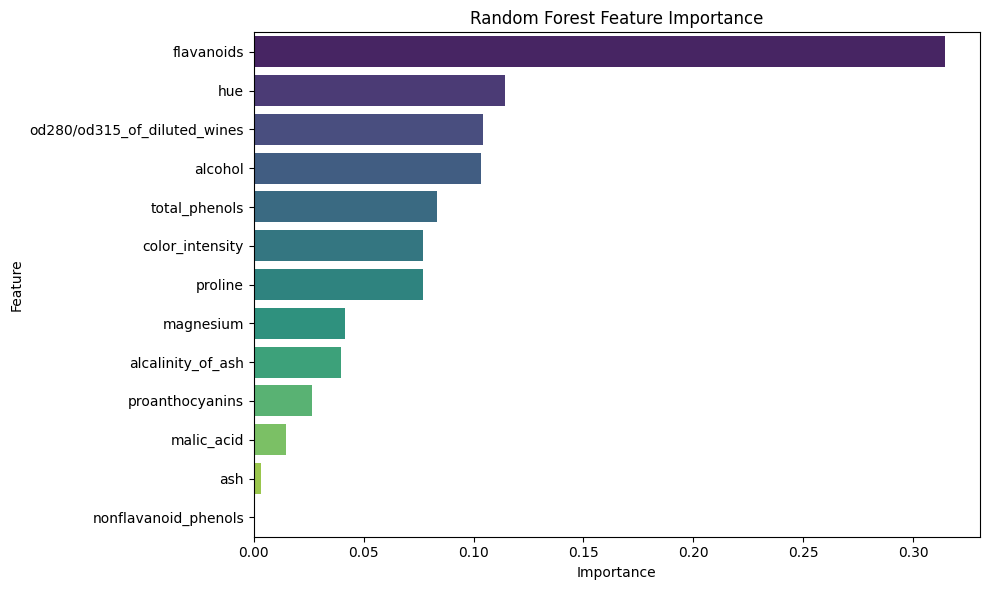

/tmp/ipykernel_5598/3939386636.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_feature_importances_gain.values, y=xgb_feature_importances_gain.index, palette='magma')


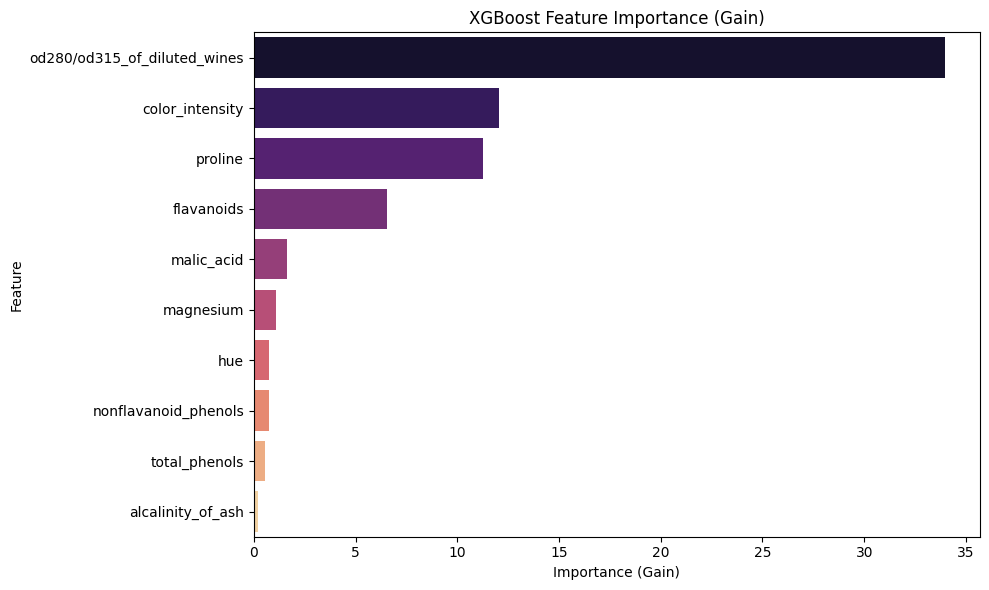

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Feature Importance para Random Forest
rf_feature_importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
rf_feature_importances = rf_feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_feature_importances.values, y=rf_feature_importances.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 2. Feature Importance para XGBoost (usando 'gain')
xgb_feature_importances_gain = best_xgb_model.get_booster().get_score(importance_type='gain')
xgb_feature_importances_gain = pd.Series(xgb_feature_importances_gain).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_feature_importances_gain.values, y=xgb_feature_importances_gain.index, palette='magma')
plt.title('XGBoost Feature Importance (Gain)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd

# Random Forest Feature Importance (as percentage)
rf_feature_importances_pct = (rf_feature_importances / rf_feature_importances.sum()) * 100
print("Random Forest Feature Importance (Percentage):")
display(rf_feature_importances_pct.to_frame(name='Percentage').round(2))

print("\nXGBoost Feature Importance (Gain Percentage):")
# XGBoost Feature Importance (as percentage of gain)
xgb_feature_importances_gain_pct = (xgb_feature_importances_gain / xgb_feature_importances_gain.sum()) * 100
display(xgb_feature_importances_gain_pct.to_frame(name='Percentage').round(2))

Random Forest Feature Importance (Percentage):


,Percentage
flavanoids,31.47
hue,11.44
od280/od315_of_diluted_wines,10.44
alcohol,10.36
total_phenols,8.35
color_intensity,7.69
proline,7.69
magnesium,4.15
alcalinity_of_ash,3.97
proanthocyanins,2.64



XGBoost Feature Importance (Gain Percentage):


,Percentage
od280/od315_of_diluted_wines,49.39
color_intensity,17.54
proline,16.39
flavanoids,9.50
malic_acid,2.36
magnesium,1.59
hue,1.08
nonflavanoid_phenols,1.06
total_phenols,0.80
alcalinity_of_ash,0.27


### Comentarios y Comparación de Rankings

El análisis de feature importance para random forest arroja cuatro features con mayor influencia la clasificacion de vinos, las cuales en conjunto representan el 60% de la relevancia:
-  `Flavanoids`, con el 31.47%
- `hue`, 11.44%
- `d280/od315_of_diluted_wines`, con un 10.44 %
- `alchohol` con un 10.36%
Con menor influencia se encuentran `total_phenols`, `color_intensity` y `proline` con un impacto el 8.35% y 7.69% respectivamente.

Por su parte, el analisis de feature importance sobre XGBoost revela que `od280/od315_of_diluted_wines` tiene el 49.39% de influencia como predictor en la clasificacion del vino, seguido por `color_intensity` y `proline` y `flavanoids` con un 17.54%, 16.3% y  9.50% respectivamente.

Adicionalmente, ambos modelos asignaron un valor casi nulo a variables como `ash` y `nonflavanoid_phenols`, por lo que su eliminación no tendria un impacto negativo en el modelo.

Se puede concluir que los resultados de Feature selection, aunque difieren en la influencia exacto de cada feature, identifican algunos featrues en su mayoria, identifican como importantes a los mismos features (`od315_of_diluted_wines`, `flavanoids`, `proline`). Sin embargo discrepan  en algunos puntos importantes, por ejemplo en la relevancia de `hue` que se encuentra en segundo lugar para Random Fores pero solo aporta un 1.08% para XGBoost.

Además, se puede apreciar que los resultados del feature importance se alinean y son coherentes con el analsis EDA realizado, donde `od315_of_diluted_wines`, `Flavanoids` y `proline` demostraron ser predictores potentes, mientras que `ash` se identifico como una variable de muy poco impacto estadístico.

#Ensamble — majority voting con bootstrap

In [34]:
import numpy as np
import pandas as pd
import time
from collections import Counter
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# =====================================================================
# 1. PREPARACIÓN DE MODELOS E HIPERPARÁMETROS
# =====================================================================

# Recuperar hiperparámetros del mejor MLP (ejemplo de tu bitácora)
best_mlp_experiment = best_models_per_family[best_models_per_family['modelo'] == 'MLPClassifier'].iloc[0]
mlp_hyperparams_str = best_mlp_experiment['hiperparametros']
mlp_hyperparams = eval(mlp_hyperparams_str)

# Inicializar las 3 familias de modelos con sus hiperparámetros ganadores
ensemble_models = [
    ('RandomForest', RandomForestClassifier(**rf_hyperparams)),
    ('XGBoost', xgb.XGBClassifier(**xgb_hyperparams)),
    ('MLPClassifier', MLPClassifier(**mlp_hyperparams))
]

# Diccionarios y listas auxiliares para el orden de los modelos
model_names = [name for name, _ in ensemble_models]
model_name_to_idx = {name: i for i, name in enumerate(model_names)}


def apply_majority_vote_with_tie_breaker(predictions_stacked, dynamic_f1_scores, model_name_to_idx):
    """
    Aplica voto mayoritario. Si hay un triple empate, usa el modelo con mayor
    F1-score dinámico calculado en esta iteración de bootstrap.
    """
    num_instances = predictions_stacked.shape[1]
    final_predictions = np.zeros(num_instances, dtype=int)

    # Ordenar los modelos de mayor a menor F1 dinámico para el desempate
    model_preference_order = sorted(dynamic_f1_scores, key=dynamic_f1_scores.get, reverse=True)

    for i in range(num_instances):
        instance_preds = predictions_stacked[:, i]  # Votos de los 3 modelos para la fila 'i'
        counts = Counter(instance_preds)

        # Encontrar la frecuencia máxima
        max_freq = max(counts.values())
        majority_preds = [pred for pred, freq in counts.items() if freq == max_freq]

        if len(majority_preds) == 1:
            # Hay una mayoría clara (3-0 o 2-1)
            final_predictions[i] = majority_preds[0]
        else:
            # TRIPLE EMPATE (1-1-1): Se activa tu regla basada en el F1 del Bootstrap actual
            for preferred_model in model_preference_order:
                model_idx = model_name_to_idx[preferred_model]
                pred_by_preferred_model = instance_preds[model_idx]

                if pred_by_preferred_model in majority_preds:
                    final_predictions[i] = pred_by_preferred_model
                    break  # Empate resuelto exitosamente

    return final_predictions


preds_test_individual = []
preds_train_individual = []
individual_train_times = []
dynamic_ensemble_f1_scores = {}

print("Ejecutando ensamble Majority Voting con Bootstrap...")

for model_name, model in ensemble_models:
    print(f"  -> Entrenando y evaluando dinámicamente: {model_name}...")

    # Generar la muestra Bootstrap con reemplazo (mismo tamaño que el X_train original)
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_train_bootstrap = X_train.iloc[idx]
    y_train_bootstrap = y_train.iloc[idx]

    # Entrenar el modelo con su respectivo dataset perturbado (Bootstrap)
    inicio_modelo = time.time()
    model.fit(X_train_bootstrap, y_train_bootstrap)
    individual_train_times.append(time.time() - inicio_modelo)

    # Predicciones individuales
    current_preds_on_test = model.predict(X_test)
    current_preds_on_train = model.predict(X_train)

    preds_test_individual.append(current_preds_on_test)
    preds_train_individual.append(current_preds_on_train)

    # CALCULO CRÍTICO: F1 dinámico obtenido en este paso para el desempate
    current_f1 = f1_score(y_test, current_preds_on_test, average='macro', zero_division=0)
    dynamic_ensemble_f1_scores[model_name] = current_f1

# Mostrar jerarquía de desempate generada dinámicamente
orden_display = sorted(dynamic_ensemble_f1_scores, key=dynamic_ensemble_f1_scores.get, reverse=True)
print(f"\nJerarquía de desempate final (Basada en F1 Test dinámico): {orden_display}\n")

# Matriz estructurada de predicciones: shape (3, n_instancias)
preds_test_stacked = np.vstack(preds_test_individual)
preds_train_stacked = np.vstack(preds_train_individual)


y_ensemble_pred_test = apply_majority_vote_with_tie_breaker(preds_test_stacked, dynamic_ensemble_f1_scores, model_name_to_idx)
y_ensemble_pred_train = apply_majority_vote_with_tie_breaker(preds_train_stacked, dynamic_ensemble_f1_scores, model_name_to_idx)

# --- Muestra visual de las primeras 5 instancias de prueba (Bug corregido) ---
print("--- Predicciones Individuales y Finales (Muestra de control) ---")
for i in range(min(5, len(X_test))):
    print(f"Instancia {i}:")
    for j, name in enumerate(model_names):
        print(f"  {name}: {preds_test_stacked[j, i]}")
    print(f"  Clase Verdadera: {y_test.iloc[i]}")
    print(f"  Predicción Final Ensamble: {y_ensemble_pred_test[i]}\n")


total_ensemble_train_time = sum(individual_train_times)

# Calculate both train and test metrics for the ensemble
ensemble_train_metrics = metricas(y_train, y_ensemble_pred_train, "train")
ensemble_test_metrics = metricas(y_test, y_ensemble_pred_test, "test")

# Combine them into a single dictionary called ensemble_metrics
ensemble_metrics = {**ensemble_train_metrics, **ensemble_test_metrics}

# Registrar en tu función personalizada
registrar(
    exp_id="Ensemble_MV_Dynamic_F1",
    modelo_nombre="Ensemble_MajorityVoting",
    hiperparams="Bootstrap + Voto Mayoritario con Desempate F1 Dinámico",
    arquitectura="Combinación RandomForest + XGBoost + MLPClassifier",
    model=None,
    X_train_data=X_train,
    y_train_labels_or_one_hot=y_train,
    X_test_data=X_test,
    y_test_labels_or_one_hot=y_test,
    tiempo_entrenamiento=total_ensemble_train_time,
    y_pred_train_override=y_ensemble_pred_train,
    y_pred_test_override=y_ensemble_pred_test
)

print(f"Resultados del Ensamble registrados exitosamente en {BITACORA}")

# Display the final ensemble metrics
print("\n Métricas Finales del Ensamble (Conjunto de Prueba y Entrenamiento):")
for metric_name, value in ensemble_metrics.items():
    print(f"  {metric_name}: {value:.4f}")

Ejecutando ensamble Majority Voting con Bootstrap...
  -> Entrenando y evaluando dinámicamente: RandomForest...
  -> Entrenando y evaluando dinámicamente: XGBoost...
  -> Entrenando y evaluando dinámicamente: MLPClassifier...

Jerarquía de desempate final (Basada en F1 Test dinámico): ['MLPClassifier', 'RandomForest', 'XGBoost']

--- Predicciones Individuales y Finales (Muestra de control) ---
Instancia 0:
  RandomForest: 2
  XGBoost: 2
  MLPClassifier: 2
  Clase Verdadera: 2
  Predicción Final Ensamble: 2

Instancia 1:
  RandomForest: 1
  XGBoost: 2
  MLPClassifier: 1
  Clase Verdadera: 1
  Predicción Final Ensamble: 1

Instancia 2:
  RandomForest: 1
  XGBoost: 1
  MLPClassifier: 1
  Clase Verdadera: 1
  Predicción Final Ensamble: 1

Instancia 3:
  RandomForest: 2
  XGBoost: 2
  MLPClassifier: 2
  Clase Verdadera: 2
  Predicción Final Ensamble: 2

Instancia 4:
  RandomForest: 0
  XGBoost: 0
  MLPClassifier: 0
  Clase Verdadera: 0
  Predicción Final Ensamble: 0

Resultados del Ensamble

## Comparación de F1-Score: Modelos Individuales vs. Ensamble

In [35]:
import pandas as pd

# Preparar los datos para el DataFrame comparativo
comparison_data = []

# Recorrer los mejores modelos individuales
for index, row in best_models_per_family.iterrows():
    model_name = row['modelo']
    f1_train = row['f1_train']
    f1_test = row['f1_test']
    comparison_data.append({'Modelo': model_name, 'F1-Score (Train)': f1_train, 'F1-Score (Test)': f1_test})

# Añadir los resultados del ensamble
comparison_data.append({
    'Modelo': 'Ensemble_MajorityVoting',
    'F1-Score (Train)': ensemble_metrics['f1_train'],
    'F1-Score (Test)': ensemble_metrics['f1_test']
})

# Crear el DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Calcular la diferencia entre F1-Score (Test) y F1-Score (Train)
comparison_df['F1-Score Difference'] = comparison_df['F1-Score (Train)'] - comparison_df['F1-Score (Test)']

# Función para clasificar el tipo de ajuste del modelo
def classify_model_fit(row):
    f1_train = row['F1-Score (Train)']
    f1_test = row['F1-Score (Test)']
    diff = row['F1-Score Difference']

    if f1_train < 0.85 and f1_test < 0.85:
        return 'Underfitting'
    elif diff > 0.08 and f1_train >= 0.85:
        return 'Overfitting'
    elif 0.05 <= diff <= 0.08 and f1_train >= 0.85:
        return 'Ligero Overfitting'
    else:
        return 'Buen Ajuste'

# Aplicar la función para crear la columna 'Model Fit'
comparison_df['Model Fit'] = comparison_df.apply(classify_model_fit, axis=1)

# Ordenar por F1-Score (Test) de forma descendente
comparison_df = comparison_df.sort_values(by='F1-Score (Test)', ascending=False).reset_index(drop=True)

display(comparison_df)


,Modelo,F1-Score (Train),F1-Score (Test),F1-Score Difference,Model Fit
0,MLPClassifier,1.000000,0.972174,0.027826,Buen Ajuste
1,RandomForest,0.992067,0.972174,0.019893,Buen Ajuste
2,Ensemble_MajorityVoting,1.000000,0.972174,0.027826,Buen Ajuste
3,XGBoost,0.992067,0.938889,0.053178,Ligero Overfitting




*   **Red Neuronal** - Tiene un F1-Score alto, tanto en train como en test (1 vs 0.972174). La diferencia en las métricas de test y train es de ~= 0.0278, una diferencia aceptable, por lo tanto se considera como un buen ajuste.
*   **Random Forest** - Tiene un F1-Score alto, tanto en train como en test(0.99 vs 0.9721). La diferencia en las métricas de test y train es de ~= 0.019893, una diferencia pequeña, por lo tanto se considera como un buen ajuste. **Se considera el modelo ganador por el ser el que tiene la menor diferencia entre train y test**
*   **Ensemble_MajorityVoting** - Tiene un F1-Score perfecto en train (1.0), pero en test este decae a 0.940186, teniendo una diferencia entre train y test de 0.059814 a favor del set de train. Se considera como un ligero overfiting por lo pequeno del del dataset. Este modelo se vio afectado por la perfección en la data de test de los modelos, pero el ligero overfiting en XGBoost. Para solucionarlo se recomienda revisar la configuracion de XGBoost para obtener una votacion con mayor consenso.
*   **XGBoostt** - Tiene un F1-Score alto, tanto en train como en test(0.99 vs 0.93889). La diferencia en las métricas de test y train es de ~= 0.053178, una diferencia pequeña, pero mayor que la obtenida en Random Forest y la Red Neuronal, y considerando lo pequeño del dataset, se puede catalogar como un ligero overfitting. Para mejorar el modelo, se sugiere una mejor regularización, agregando `reg_lambda` para suavizar las fronteras de decision, reducir el `learning_rate` de 0.15 a 0.1, para evitar un ajuste demasiado agresivo en la data de entrenamiento.


